In [ ]:
# ============================================
# Cell 1: Environment Setup with ALL MedSAM2 Checkpoints
# ============================================
# Run this cell first to set up the environment
# Make sure to use GPU: Runtime → Change runtime type → GPU

# Install dependencies
!git clone https://github.com/bowang-lab/MedSAM2.git
%cd MedSAM2
%pip install -e .
# Install additional dependencies for metrics calculation
!pip install medpy

# Download ALL available model checkpoints
!mkdir -p checkpoints

print("Downloading all available MedSAM2 checkpoints...")

# Download script location
!wget https://raw.githubusercontent.com/bowang-lab/MedSAM2/main/download.sh
!chmod +x download.sh

# Execute the download script to download all weights
!./download.sh

# Alternatively, you can manually download each weight (if the script method above doesn't work).
"""
# Alternative solution: Manually download each weight
checkpoints_to_download = {
    "MedSAM2_2411.pt": "Basic model (November 2024 version)",
    "MedSAM2_US_Heart.pt": "Dedicated to cardiac ultrasound video segmentation",
    "MedSAM2_MRI_LiverLesion.pt": "MRI segmentation for liver lesions",
    "MedSAM2_CTLesion.pt": "CT lesion segmentation",
    "MedSAM2_latest.pt": "Latest Recommendation Model"
}

# If the automatic download fails, uncomment the code below to download manually.
# for checkpoint_name, description in checkpoints_to_download.items():
#     print(f"\nDownloading {checkpoint_name} - {description}")
#     # This requires a specific download URL, which may need to be obtained from GitHub.
#     !wget -P checkpoints [Specific download URL]
"""

# List the weights of all downloads.
import os
checkpoint_files = sorted([f for f in os.listdir('checkpoints') if f.endswith('.pt')])
print(f"\nThe weight file was successfully downloaded:")
for i, ckpt in enumerate(checkpoint_files):
    file_size = os.path.getsize(os.path.join('checkpoints', ckpt)) / (1024**2)
    print(f"{i+1}. {ckpt} ({file_size:.1f} MB)")

# Weight file description
print("\n" + "="*60)
print("Weight file description:")
print("="*60)
print("1. MedSAM2_2411.pt - Basic general model")
print("2. MedSAM2_US_Heart.pt - For cardiac ultrasound (Not suitable for your CT vascular data)")
print("3. MedSAM2_MRI_LiverLesion.pt - For liver MRI lesions")
print("4. MedSAM2_CTLesion.pt - For CT lesions (May be suitable)")
print("5. MedSAM2_latest.pt - Latest model (Recommended to try)")
print("\nFor your liver vascular CT data, it is recommended to try this first:")
print("- MedSAM2_latest.pt (Latest version)")
print("- MedSAM2_CTLesion.pt (CT specific)")
print("- MedSAM2_2411.pt (Basic version)")


Cloning into 'MedSAM2'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 297 (delta 90), reused 63 (delta 63), pack-reused 144 (from 1)
Receiving objects: 100% (297/297), 18.82 MiB | 8.27 MiB/s, done.
Resolving deltas: 100% (122/122), done.
/content/MedSAM2
Obtaining file:///content/MedSAM2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.5 MB/s eta 0:00:00
  Building editable for MedSAM2 (pyproject.toml) ... done
  Created wheel for MedSAM2: filename=medsam2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=10556 sha256=087eab2d8a424380180de2a7efb0

In [ ]:
# ============================================
# Cell 1.1: Google drive
# ============================================
# Mount Google Drive to access custom dataset
from google.colab import drive
drive.mount('/content/drive')
print("\nSetup complete!")

Mounted at /content/drive

Setup complete!


In [ ]:
# ============================================
# Cell 2: Import libraries and define functions
# ============================================
# Import all necessary libraries
from glob import glob
from tqdm import tqdm
import os
from os.path import join, basename
import re
import matplotlib.pyplot as plt
from collections import OrderedDict
import pandas as pd
import numpy as np
import argparse
import json

from PIL import Image
import torch
import torch.multiprocessing as mp
from sam2.build_sam import build_sam2_video_predictor_npz
import SimpleITK as sitk
from skimage import measure, morphology
from medpy.metric.binary import hd95 as compute_hd95
from datetime import datetime

torch.set_float32_matmul_precision('high')
torch.manual_seed(2024)
torch.cuda.manual_seed(2024)
np.random.seed(2024)


def getLargestCC(segmentation):
    labels = measure.label(segmentation)
    largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1
    return largestCC

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """
    show mask on the image

    Parameters
    ----------
    mask : numpy.ndarray
        mask of the image
    ax : matplotlib.axes.Axes
        axes to plot the mask
    mask_color : numpy.ndarray
        color of the mask
    alpha : float
        transparency of the mask
    """
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax, edgecolor='blue'):
    """
    show bounding box on the image

    Parameters
    ----------
    box : numpy.ndarray
        bounding box coordinates in the original image
    ax : matplotlib.axes.Axes
        axes to plot the bounding box
    edgecolor : str
        color of the bounding box
    """
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=edgecolor, facecolor=(0,0,0,0), lw=2))


def resize_grayscale_to_rgb_and_resize(array, image_size):
    """
    Resize a 3D grayscale NumPy array to an RGB image and then resize it.

    Parameters:
        array (np.ndarray): Input array of shape (d, h, w).
        image_size (int): Desired size for the width and height.

    Returns:
        np.ndarray: Resized array of shape (d, 3, image_size, image_size).
    """
    d, h, w = array.shape
    resized_array = np.zeros((d, 3, image_size, image_size))

    for i in range(d):
        img_pil = Image.fromarray(array[i].astype(np.uint8))
        img_rgb = img_pil.convert("RGB")
        img_resized = img_rgb.resize((image_size, image_size))
        img_array = np.array(img_resized).transpose(2, 0, 1)  # (3, image_size, image_size)
        resized_array[i] = img_array

    return resized_array

# Add metrics calculation functions
def calculate_metrics(pred, gt):
    """
    Calculate segmentation metrics: IoU, Dice, and HD95

    Parameters:
        pred: predicted segmentation mask (binary)
        gt: ground truth segmentation mask (binary)

    Returns:
        dict: containing IoU, Dice, and HD95 metrics
    """
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    # Calculate intersection and union
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    # IoU
    iou = intersection / (union + 1e-8)

    # Dice
    dice = 2 * intersection / (pred.sum() + gt.sum() + 1e-8)

    # HD95 - handle edge cases
    try:
        if pred.sum() > 0 and gt.sum() > 0:
            hd95_score = compute_hd95(pred, gt)
        else:
            hd95_score = np.inf
    except:
        hd95_score = np.inf

    return {
        'iou': iou,
        'dice': dice,
        'hd95': hd95_score
    }

# Calculate per-class IoU and Dice
def calculate_metrics_per_class(pred_binary, gt_multiclass):
  per_class_iou = {}
  per_class_dice = {}

  unique_labels = np.unique(gt_multiclass)
  unique_labels = unique_labels[unique_labels > 0]

  for label in unique_labels:
        # Current class in GT
        gt_class = (gt_multiclass == label).astype(bool)

        # Overlap between prediction and this class GT is treated as predictions for this class
        pred_class = np.logical_and(pred_binary > 0, gt_class)

        # Calculate IoU for this class
        intersection = np.logical_and(pred_class, gt_class).sum()
        union = np.logical_or(pred_class, gt_class).sum()

        if union > 0:
            iou = intersection / union
        else:
            iou = 0.0

        # Calculate Dice for this class
        if (pred_class.sum() + gt_class.sum()) > 0:
            dice = 2 * intersection / (pred_class.sum() + gt_class.sum())
        else:
            dice = 0.0

        per_class_iou[int(label)] = iou
        per_class_dice[int(label)] = dice
  return per_class_iou, per_class_dice

# Add new calculation function
def calculate_metrics_force_multiclass(pred_binary, gt_multiclass):
    """
    Forced calculation of multi-class metrics, even if the prediction is binary.
    By assigning the predicted foreground region to different GT categories.
    """
    # Get all categories (excluding background 0).
    unique_labels = np.unique(gt_multiclass)
    unique_labels = unique_labels[unique_labels > 0]

    if len(unique_labels) == 0:
        return {
            'mIoU': 0.0,
            'aIoU': 0.0,
            'mDice': 0.0,
            'aDice': 0.0,
            'hd95': np.inf
        }

    # Assign predictions to each GT category
    per_class_iou, per_class_dice = calculate_metrics_per_class(pred_binary, gt_multiclass)

    # Calculate mIoU (simple average)
    mIoU = np.mean(list(per_class_iou.values()))

    # Calculate mDice (simple average)
    mDice = np.mean(list(per_class_dice.values()))

    # Calculate the class-agnostic metric
    # Merge all foreground categories into a single category
    # Change all labels from [0, 1, 2] to [0, 1, 1] and calculate adice and aiou.
    a_gt_multiclass = gt_multiclass.copy()
    a_gt_multiclass[a_gt_multiclass == 2] = 1  # All binary values become 1
    a_per_class_iou, a_per_class_dice = calculate_metrics_per_class(pred_binary, a_gt_multiclass)


    # calculate aIoU
    aIoU = np.mean(list(a_per_class_iou.values()))

    # calculate aDice
    aDice = np.mean(list(a_per_class_dice.values()))


    # old: calculate aIoU (weighted average)
    # total_pixels = 0
    # weighted_iou = 0
    # for label in unique_labels:
    #     gt_pixels = (gt_multiclass == label).sum()
    #     total_pixels += gt_pixels
    #     weighted_iou += per_class_iou[int(label)] * gt_pixels

    # aIoU = weighted_iou / total_pixels if total_pixels > 0 else 0.0

    # Old: Calculate aDice (weighted average)
    # weighted_dice = 0
    # for label in unique_labels:
    #     gt_pixels = (gt_multiclass == label).sum()
    #     weighted_dice += per_class_dice[int(label)] * gt_pixels

    # aDice = weighted_dice / total_pixels if total_pixels > 0 else 0.0

    # HD95(Calculated using the overall binary mask)
    gt_binary = (gt_multiclass > 0).astype(bool)
    pred_binary_bool = pred_binary.astype(bool)

    try:
        if pred_binary_bool.sum() > 0 and gt_binary.sum() > 0:
            hd95_score = compute_hd95(pred_binary_bool, gt_binary)
        else:
            hd95_score = np.inf
    except:
        hd95_score = np.inf

    return {
        'mIoU': mIoU,
        'aIoU': aIoU,
        'mDice': mDice,
        'aDice': aDice,
        'hd95': hd95_score,
        'per_class_iou': per_class_iou,
        'per_class_dice': per_class_dice
    }

def get_bounding_box_from_mask(mask):
    """
    Get bounding box from binary mask

    Parameters:
        mask: binary mask

    Returns:
        bbox: [x_min, y_min, x_max, y_max] or None if mask is empty
    """
    if mask.sum() == 0:
        return None

    positions = np.where(mask)
    y_min = positions[0].min()
    y_max = positions[0].max()
    x_min = positions[1].min()
    x_max = positions[1].max()

    return np.array([x_min, y_min, x_max, y_max])

print("Functions loaded successfully!")


Functions loaded successfully!


In [ ]:
# ============================================
# Cell 3: Set paths and select checkpoint
# ============================================

import os

# List all available weights
checkpoint_dir = './checkpoints'
available_checkpoints = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith('.pt')])

# checkpoint descriptions
checkpoint_descriptions = {
    "MedSAM2_2411.pt": "Base model",
    "MedSAM2_US_Heart.pt": "Heart ultrasound",
    "MedSAM2_MRI_LiverLesion.pt": "Liver MRI lesion",
    "MedSAM2_CTLesion.pt": "CT lesion - Recommended",
    "MedSAM2_latest.pt": "Latest model - Highly recommended"
}

print("Available checkpoints:")
print("="*60)
for i, ckpt in enumerate(available_checkpoints):
    file_size = os.path.getsize(os.path.join(checkpoint_dir, ckpt)) / (1024**2)
    desc = checkpoint_descriptions.get(ckpt, "Unknown model")
    print(f"{i+1}. {ckpt} ({file_size:.1f} MB)")
    print(f"   {desc}")
print("="*60)

# ========== Select the weights to use here ==========
# Method 1: Directly specify the weight name (Recommended)
CHECKPOINT_NAME = "MedSAM2_US_Heart.pt"  # <-- Modify here to switch weights

# Method 2: Select by index (uncomment to use)
# checkpoint_index = 4  # Choose the 5th weight (MedSAM2_latest.pt)
# CHECKPOINT_NAME = available_checkpoints[checkpoint_index]

print(f"\nCurrent selected weight:{CHECKPOINT_NAME}")
print(f"illustrate: {checkpoint_descriptions.get(CHECKPOINT_NAME, 'Unknown model')}")

# Set weight path
checkpoint = os.path.join(checkpoint_dir, CHECKPOINT_NAME)
if not os.path.exists(checkpoint):
    print(f"\nError: Weight file {checkpoint} does not exist!")
    print("Please ensure that Cell 1 has been run and all weights have been downloaded.")
else:
    print(f"\nWeight file path: {checkpoint}")
    print("The weight file exists; you can continue running.")

# Model configuration
model_cfg = "configs/sam2.1_hiera_t512.yaml"


# ========== Here, select the enhancement method to use. ==========
images_augmentation = {
  'augmentation_gamma_correction': 'Gamma Correction Gamma correction: Adjust the global brightness curve, with the γ value randomly selected between 0.8 and 1.2.',
  'augmentation_contrast_enhancement': 'Contrast Enhancement: Scaling factor is 1.1~1.3 (moderate enhancement, without causing pixel saturation).',
  'augmentation_gaussian_blur': 'Gaussian Blur: Sigma value of 0.5~1.5 (slightly smooths the surface, without blurring until lesions disappear).',
  'augmentation_noise': 'Noise injection: The noise intensity is taken as 5% to 10% of the standard deviation of the original image (weak noise, which does not cover the lesion).'
}

# Set timestamp
timestamp = datetime.now().strftime("%m%d")

# augmentation path
aug_type = 'augmentation_noise' # <-- Modify here to switch enhancements
augmentation_var = f'{aug_type}_{timestamp}'

# Custom dataset paths from Google Drive
dataset_name = 'UMD'
path = {
    'dataset': '/content/drive/MyDrive/SegTTA/dataset/UMD',
    'result': '/content/drive/MyDrive/SegTTA/results/UMD'
}


# annotation label path
labels_path = os.path.join(path['dataset'], 'binary_labels')

# volume/image path
imgs_path = os.path.join(path['result'], augmentation_var) if aug_type else os.path.join(path['dataset'], 'images')

dataset_path = os.path.join(path['result'], augmentation_var) if aug_type else path['dataset']


# Output paths - Create different results folders based on weight name/enhancement method.
checkpoint_suffix = CHECKPOINT_NAME.replace('.pt', '').replace('MedSAM2_', '')

# pred path
pred_save_dir = os.path.join(path['result'], f'MedSAM2_results_{checkpoint_suffix}_{augmentation_var}') if aug_type else os.path.join(path['result'], f'MedSAM2_results_{checkpoint_suffix}_{timestamp}')


os.makedirs(pred_save_dir, exist_ok=True)
print(f"Results will be saved to: {pred_save_dir}")

# Create subfolders to organize different types of output.
predictions_dir = os.path.join(pred_save_dir, 'predictions')
visualizations_dir = os.path.join(pred_save_dir, 'visualizations')
metrics_dir = os.path.join(pred_save_dir, 'metrics')

os.makedirs(predictions_dir, exist_ok=True)
os.makedirs(visualizations_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

# Update indicator save path
metrics_save_path = os.path.join(metrics_dir, 'performance_metrics.json')

# Get list of all image files
image_files = sorted([f for f in os.listdir(imgs_path) if f.endswith('.nii.gz') and not f.startswith('._')])
print(f"\nFound {len(image_files)} real images in the dataset")

if len(image_files) == 0:
    print("No valid image files found!")
    print("Checking directory contents...")
    all_files = os.listdir(imgs_path)
    print(f"Total files in directory: {len(all_files)}")
    print("Sample files:", all_files[:10])
else:
    print("Sample image files:", image_files[:5])

# Also check the tag file.
label_files = sorted([f for f in os.listdir(labels_path) if f.endswith('.nii.gz') and not f.startswith('._')])
print(f"Found {len(label_files)} real labels in the dataset")

if aug_type:
  print(f'Current dataset: {dataset_path}')
else:
  print("\nDirectory structure created:")
  print(f"├── {dataset_path}/")
  print(f"│   ├── MedSAM2_results_{checkpoint_suffix}/")
  print(f"│   │   ├── predictions/     (segmentation masks)")
  print(f"│   │   ├── visualizations/  (PNG images)")
  print(f"│   │   └── metrics/         (JSON and CSV files)")

# Experiment configuration summary
print("\n" + "="*60)
print("Experiment configuration summary:")
print("="*60)
print(f"Weight file: {CHECKPOINT_NAME}")
print(f"Dataset: {dataset_name} ({len(image_files)} files)")
print(f"Result saving path: {pred_save_dir}")
print("="*60)

可用的权重文件 (Available checkpoints):
1. MedSAM2_2411.pt (148.8 MB)
   基础通用模型 (Base model)
2. MedSAM2_CTLesion.pt (148.8 MB)
   CT病变专用 (CT lesion) - 推荐
3. MedSAM2_MRI_LiverLesion.pt (148.8 MB)
   肝脏MRI病变专用 (Liver MRI lesion)
4. MedSAM2_US_Heart.pt (148.8 MB)
   心脏超声专用 (Heart ultrasound)
5. MedSAM2_latest.pt (148.8 MB)
   最新模型 (Latest) - 强烈推荐
6. efficienttam_s_512x512.pt (130.1 MB)
   未知模型
7. efficienttam_ti_512x512.pt (68.3 MB)
   未知模型
8. sam2.1_hiera_tiny.pt (148.8 MB)
   未知模型

当前选择的权重: MedSAM2_US_Heart.pt
说明: 心脏超声专用 (Heart ultrasound)

权重文件路径: ./checkpoints/MedSAM2_US_Heart.pt
✓ 权重文件存在，可以继续运行
Results will be saved to: /content/drive/MyDrive/SegTTA-SCI/results/UMD/MedSAM2_results_US_Heart_augmentation_noise_0905

Found 300 real images in the dataset
Sample image files: ['UMD_221129_001_t2.nii.gz', 'UMD_221129_002_t2.nii.gz', 'UMD_221129_003_t2.nii.gz', 'UMD_221129_004_t2.nii.gz', 'UMD_221129_005_t2.nii.gz']
Found 300 real labels in the dataset
Current dataset: /content/drive/MyDrive/SegTTA

In [ ]:
# ============================================
# Cell 4: Run Inference on Custom Dataset
# ============================================
import re
from collections import OrderedDict
from tqdm import tqdm
import numpy as np
import torch
import SimpleITK as sitk
import os
import time
import gc

# Initialize predictor
predictor = build_sam2_video_predictor_npz(model_cfg, checkpoint)

# Storage for metrics
all_metrics = []
seg_info = OrderedDict()
seg_info['image_name'] = []
seg_info['mIoU'] = []   # name change
seg_info['aIoU'] = []   # New Added
seg_info['mDice'] = []  # name change
seg_info['aDice'] = []  # New Added
seg_info['hd95'] = []

def extract_prefix(filename):
    """
    Extract the prefix of the filename (including the name and numbers).

    Sample:
    'UMD_221129_001_t2.nii.gz' -> 'UMD_221129_001'
    'UMD_221129_001_seg_bin.nii.gz' -> 'UMD_221129_001'
    """
    # Remove the .nii.gz extension
    base_name = filename.replace('.nii.gz', '')

    # Method 1: Matching pattern "alphanumeric_number"
    pattern = r'^([A-Za-z]+_\d+_\d+)'
    match = re.match(pattern, base_name)
    if match:
        return match.group(1)

    # Method 2: If the filename contains a suffix such as _seg_bin or _t2, extract the part before it.
    # Find the content before the last underscore. If this content matches the format "alphanumeric_number",...
    parts = base_name.split('_')
    if len(parts) >= 3:
        # Attempt to reorganize the first three parts
        potential_prefix = '_'.join(parts[:3])
        # Check if it conforms to the "letter_number_number" format.
        if re.match(r'^[A-Za-z]+_\d+_\d+$', potential_prefix):
            return potential_prefix

    # Method 3: Alternative Solution - Return to the part with known suffixes removed
    known_suffixes = ['_t2', '_seg_bin', '_seg', '_label', '_mask']
    for suffix in known_suffixes:
        if suffix in base_name:
            return base_name.split(suffix)[0]

    return None

def safe_save_nifti(sitk_image, save_path, original_image=None, max_retries=3):
    """
    Securely save NIfTI files, including error handling and retry mechanisms.
    """
    for attempt in range(max_retries):
        try:
            # Ensure the target directory exists
            os.makedirs(os.path.dirname(save_path), exist_ok=True)

            # Check disk behavior (special handling for Google Drive)
            if '/content/drive' in save_path:
                # Wait briefly for Google Drive to sync
                time.sleep(0.5)

            # Try different saving methods
            if attempt == 0:
                # Method 1: Save directly
                sitk.WriteImage(sitk_image, save_path)
            elif attempt == 1:
                # Method 2: Save locally first, then move to Google Drive
                temp_path = f"/tmp/{os.path.basename(save_path)}"
                sitk.WriteImage(sitk_image, temp_path)

                # Read the temporary file and save it to the target path
                temp_img = sitk.ReadImage(temp_path)
                sitk.WriteImage(temp_img, save_path)

                # Remove the temporary file
                if os.path.exists(temp_path):
                    os.remove(temp_path)
            else:
                # Method 3: Use a different compression setting
                writer = sitk.ImageFileWriter()
                writer.SetFileName(save_path)
                writer.SetUseCompression(False)  # Try saving without compression
                writer.Execute(sitk_image)

            print(f"Successfully saved: {os.path.basename(save_path)}")
            return True

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {str(e)}")
            if attempt < max_retries - 1:
                print(f"Retrying in 2 seconds...")
                time.sleep(2)
                # Clean up memory
                gc.collect()
            else:
                print(f"Failed to save {save_path} after {max_retries} attempts")
                return False

    return False

# Process each image
for img_name in tqdm(image_files, desc="Processing images"):
    try:
        # Load image and corresponding label
        img_path = os.path.join(imgs_path, img_name)

        # Extract the file prefix
        img_prefix = extract_prefix(img_name)

        if img_prefix is None:
            print(f"Cannot extract prefix from {img_name}, skipping...")
            continue

        # Find the corresponding label file based on the prefix
        label_name = None
        label_path = None

        # First, try using the exact same file name
        if img_name in os.listdir(labels_path):
            label_name = img_name
            label_path = os.path.join(labels_path, label_name)
        else:
            # Search for a label file with the same prefix
            for potential_label in os.listdir(labels_path):
                label_prefix = extract_prefix(potential_label)
                if label_prefix == img_prefix:
                    label_name = potential_label
                    label_path = os.path.join(labels_path, label_name)
                    break

        # If still not found, try other naming conventions
        if label_path is None or not os.path.exists(label_path):
            print(f"Label not found for {img_name} with prefix {img_prefix}, trying alternative names...")

            # Try other possible naming conventions
            alternative_names = [
                img_name.replace('.nii.gz', '_label.nii.gz'),
                img_name.replace('_t2.nii.gz', '_seg_bin.nii.gz'),
                img_name.replace('_t2.nii.gz', '_seg.nii.gz'),
                f'{img_prefix}_seg_bin.nii.gz',
                f'{img_prefix}_seg.nii.gz',
                f'{img_prefix}_label.nii.gz',
                'label_' + img_name,
                img_name.replace('image', 'label'),
            ]

            for alt_name in alternative_names:
                alt_path = os.path.join(labels_path, alt_name)
                if os.path.exists(alt_path):
                    label_path = alt_path
                    print(f"Found label: {alt_name}")
                    break
            else:
                print(f"Skipping {img_name}: No corresponding label found")
                continue

        # Read image and label
        nii_image = sitk.ReadImage(img_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)

        nii_label = sitk.ReadImage(label_path)
        nii_label_data = sitk.GetArrayFromImage(nii_label)

        # Debug: print image and label information
        print(f"\nProcessing: {img_name}")
        print(f"Image shape: {nii_image_data.shape}, dtype: {nii_image_data.dtype}")
        print(f"Label shape: {nii_label_data.shape}, dtype: {nii_label_data.dtype}")
        unique_labels = np.unique(nii_label_data)
        print(f"Unique labels: {unique_labels}")

        # Preprocess image (normalize to 0-255)
        nii_image_data_pre = nii_image_data.astype(np.float32)
        nii_image_data_pre = np.clip(nii_image_data_pre,
                                     np.percentile(nii_image_data_pre, 0.5),
                                     np.percentile(nii_image_data_pre, 99.5))
        nii_image_data_pre = (nii_image_data_pre - np.min(nii_image_data_pre)) / \
                            (np.max(nii_image_data_pre) - np.min(nii_image_data_pre)) * 255.0
        nii_image_data_pre = np.uint8(nii_image_data_pre)

        # Find key slice (slice with largest label area)
        label_areas = np.sum(nii_label_data > 0, axis=(1, 2))
        if label_areas.sum() == 0:
            print(f"Skipping {img_name}: No label found")
            continue

        key_slice_idx = np.argmax(label_areas)
        print(f"Key slice index: {key_slice_idx}")

        # Get bounding box from label
        key_slice_label = nii_label_data[key_slice_idx]
        bbox = get_bounding_box_from_mask(key_slice_label > 0)

        if bbox is None:
            print(f"Skipping {img_name}: No valid bounding box")
            continue

        # Prepare image for SAM2
        img_3D_ori = nii_image_data_pre
        video_height = img_3D_ori.shape[1]
        video_width = img_3D_ori.shape[2]

        img_resized = resize_grayscale_to_rgb_and_resize(img_3D_ori, 512)
        img_resized = img_resized / 255.0
        img_resized = torch.from_numpy(img_resized).cuda()

        # Normalize
        img_mean = (0.485, 0.456, 0.406)
        img_std = (0.229, 0.224, 0.225)
        img_mean = torch.tensor(img_mean, dtype=torch.float32)[:, None, None].cuda()
        img_std = torch.tensor(img_std, dtype=torch.float32)[:, None, None].cuda()
        img_resized -= img_mean
        img_resized /= img_std

        # Initialize segmentation
        segs_3D = np.zeros(nii_image_data.shape, dtype=np.uint8)

        # Run inference
        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            inference_state = predictor.init_state(img_resized, video_height, video_width)

            # Add box prompt at key slice
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=key_slice_idx,
                obj_id=1,
                box=bbox,
            )

            # Forward propagation
            for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
                segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

            predictor.reset_state(inference_state)

            # Re-add box prompt for backward propagation
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=key_slice_idx,
                obj_id=1,
                box=bbox,
            )

            # Backward propagation
            for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
                segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

            predictor.reset_state(inference_state)

        # Post-processing
        if np.max(segs_3D) > 0:
            segs_3D = getLargestCC(segs_3D)
            segs_3D = np.uint8(segs_3D)

        print(f"Segmentation shape: {segs_3D.shape}, dtype: {segs_3D.dtype}")
        print(f"Segmentation unique values: {np.unique(segs_3D)}")

        # Calculate metrics - use the new multi-class calculation method
        # Note: the original multi-class labels are used here instead of binary labels
        metrics = calculate_metrics_force_multiclass(segs_3D, nii_label_data)

        # Store results - save all metrics
        seg_info['image_name'].append(img_name)
        seg_info['mIoU'].append(metrics['mIoU'])
        seg_info['aIoU'].append(metrics['aIoU'])
        seg_info['mDice'].append(metrics['mDice'])
        seg_info['aDice'].append(metrics['aDice'])
        seg_info['hd95'].append(metrics['hd95'])
        all_metrics.append(metrics)

        # Updated print message
        print(f"Metrics - mIoU={metrics['mIoU']:.4f}, aIoU={metrics['aIoU']:.4f}, "
              f"mDice={metrics['mDice']:.4f}, aDice={metrics['aDice']:.4f}, HD95={metrics['hd95']:.4f}")

        # Save segmentation - use the safe save function
        try:
            # Create a SimpleITK image
            sitk_mask = sitk.GetImageFromArray(segs_3D.astype(np.uint8))

            # Copy the metadata from the original image
            sitk_mask.CopyInformation(nii_image)

            # Use the prefix to generate the prediction file name
            save_name = f"{img_prefix}_pred.nii.gz"
            save_path = os.path.join(predictions_dir, save_name)

            # Use the safe save function
            if safe_save_nifti(sitk_mask, save_path, nii_image):
                print(f"✓ Saved prediction: {save_name}")
            else:
                print(f"✗ Failed to save prediction: {save_name}")
                # Continue processing the next image without interruption

        except Exception as save_error:
            print(f"Error saving prediction: {str(save_error)}")
            # Try saving to a temporary directory
            try:
                temp_save_name = f"{img_prefix}_pred.nii.gz"
                temp_save_path = f"/tmp/{temp_save_name}"
                sitk.WriteImage(sitk_mask, temp_save_path)
                print(f"Saved to temporary location: {temp_save_path}")
            except:
                print(f"Could not save to temporary location either")

    except Exception as e:
        print(f"Error processing {img_name}: {str(e)}")
        import traceback
        traceback.print_exc()  # Print detailed error information
        continue

    # Clean up memory periodically
    if len(seg_info['image_name']) % 10 == 0:
        gc.collect()
        torch.cuda.empty_cache()

# Print summary information
print("\n" + "="*50)
print("Processing Complete!")
print(f"Total images processed: {len(seg_info['image_name'])}")
if len(seg_info['image_name']) > 0:
    print(f"Average mIoU: {np.mean(seg_info['mIoU']):.4f}")
    print(f"Average aIoU: {np.mean(seg_info['aIoU']):.4f}")
    print(f"Average mDice: {np.mean(seg_info['mDice']):.4f}")
    print(f"Average aDice: {np.mean(seg_info['aDice']):.4f}")

    # Processing inf values
    hd95_values = [x for x in seg_info['hd95'] if not np.isinf(x)]
    if hd95_values:
        print(f"Average HD95 (excluding inf): {np.mean(hd95_values):.4f}")
        print(f"Number of inf HD95 values: {len(seg_info['hd95']) - len(hd95_values)}")
    else:
        print("All HD95 values are inf")
print("="*50)

Processing images:   0%|          | 0/300 [00:00<?, ?it/s]


Processing: UMD_221129_001_t2.nii.gz
Image shape: (20, 672, 672), dtype: float32
Label shape: (20, 672, 672), dtype: uint8
Unique labels: [0 1]
Key slice index: 4



propagate in video: 100%|██████████| 16/16 [00:00<00:00, 38.66it/s]

propagate in video: 100%|██████████| 5/5 [00:00<00:00, 47.00it/s]


Segmentation shape: (20, 672, 672), dtype: uint8
Segmentation unique values: [0 1]
Metrics - mIoU=0.9306, aIoU=0.9306, mDice=0.9640, aDice=0.9640, HD95=71.8592


Processing images:   0%|          | 1/300 [00:05<26:32,  5.33s/it]

...

Successfully saved: UMD_221129_299_pred.nii.gz
✓ Saved prediction: UMD_221129_299_pred.nii.gz

Processing: UMD_221129_300_t2.nii.gz
Image shape: (24, 576, 576), dtype: float32
Label shape: (24, 576, 576), dtype: uint8
Unique labels: [0 1]
Key slice index: 17



propagate in video: 100%|██████████| 7/7 [00:00<00:00, 42.62it/s]

propagate in video: 100%|██████████| 18/18 [00:00<00:00, 39.66it/s]


Segmentation shape: (24, 576, 576), dtype: uint8
Segmentation unique values: [0 1]
Metrics - mIoU=0.9735, aIoU=0.9735, mDice=0.9866, aDice=0.9866, HD95=17.7482


Processing images: 100%|██████████| 300/300 [26:06<00:00,  5.22s/it]

Successfully saved: UMD_221129_300_pred.nii.gz
✓ Saved prediction: UMD_221129_300_pred.nii.gz

Processing Complete!
Total images processed: 300
Average mIoU: 0.8507
Average aIoU: 0.8507
Average mDice: 0.8899
Average aDice: 0.8899
Average HD95 (excluding inf): 44.4577
Number of inf HD95 values: 0


In [ ]:
# ============================================
# Cell 4.1: Simpele Check Data
# ============================================
print(seg_info['mIoU'])
print(seg_info['aIoU'])
print(seg_info['mDice'])
print(seg_info['aDice'])
print(seg_info['hd95'])

[np.float64(0.9305555555555556), np.float64(0.7844886753603294), np.float64(0.9934167215273206), np.float64(0.8348082595870207), np.float64(0.9727767695099818), np.float64(0.9981122486023379), np.float64(0.6387912860154603), np.float64(0.9321947489166454), np.float64(0.9843691637597574), np.float64(0.9666666666666667), np.float64(0.9898883084113944), np.float64(0.7470271623482289), np.float64(0.9996405463695184), np.float64(0.827806886227545), np.float64(0.8919949174078781), np.float64(0.44144182707590524), np.float64(0.9399719841793013), np.float64(0.8266242937853108), np.float64(0.8351747463359639), np.float64(0.5212121212121212), np.float64(0.8966660167674011), np.float64(0.0), np.float64(0.9917903619357462), np.float64(0.9712515188335359), np.float64(0.9815402365157196), np.float64(0.9739336492890995), np.float64(0.9576644097148291), np.float64(0.846401028277635), np.float64(0.9608908952714375), np.float64(0.9285714285714286), np.float64(0.9744882824087808), np.float64(0.9203377386

In [ ]:
# ============================================
# Cell 5: Calculate Final Performance Metrics
# ============================================

print("Verifying metric relationships...")
for i, (name, metrics) in enumerate(zip(seg_info['image_name'][:5], all_metrics[:5])):
    print(f"\n{name}:")
    print(f"  aIoU ({metrics['aIoU']:.4f}) >= mIoU ({metrics['mIoU']:.4f}): {'✓' if metrics['aIoU'] >= metrics['mIoU'] else '✗'}")
    print(f"  aDice ({metrics['aDice']:.4f}) >= mDice ({metrics['mDice']:.4f}): {'✓' if metrics['aDice'] >= metrics['mDice'] else '✗'}")

# Check overall statistics
aious = [m['aIoU'] for m in all_metrics]
mious = [m['mIoU'] for m in all_metrics]
adices = [m['aDice'] for m in all_metrics]
mdices = [m['mDice'] for m in all_metrics]

print(f"\nOverall statistics:")
print(f"Mean aIoU: {np.mean(aious):.4f}")
print(f"Mean mIoU: {np.mean(mious):.4f}")
print(f"Mean aDice: {np.mean(adices):.4f}")
print(f"Mean mDice: {np.mean(mdices):.4f}")
print(f"\nRelationship check: aIoU >= mIoU: {'✓' if np.mean(aious) >= np.mean(mious) else '✗'}")
print(f"Relationship check: aDice >= mDice: {'✓' if np.mean(adices) >= np.mean(mdices) else '✗'}")

# Calculate aggregate metrics
if all_metrics:
    # Extract individual metric lists
    mious = [m['mIoU'] for m in all_metrics]
    aious = [m['aIoU'] for m in all_metrics]
    mdices = [m['mDice'] for m in all_metrics]
    adices = [m['aDice'] for m in all_metrics]
    hd95s = [m['hd95'] for m in all_metrics if m['hd95'] != np.inf]

    # Calculate mean and average metrics
    final_metrics = {
        'mIoU': np.mean(mious),
        'aIoU': np.mean(aious),
        'mDice': np.mean(mdices),
        'aDice': np.mean(adices),
        'HD95': np.mean(hd95s) if hd95s else np.inf,
        'num_cases': len(all_metrics),
        'num_valid_hd95': len(hd95s)
    }

    # Print results
    print("\n" + "="*50)
    print("FINAL PERFORMANCE METRICS (Baseline)")
    print("="*50)
    print(f"mIoU: {final_metrics['mIoU']:.4f}")
    print(f"aIoU: {final_metrics['aIoU']:.4f}")
    print(f"mDice: {final_metrics['mDice']:.4f}")
    print(f"aDice: {final_metrics['aDice']:.4f}")
    print(f"HD95: {final_metrics['HD95']:.2f}")
    print(f"\nProcessed {final_metrics['num_cases']} cases")
    print(f"Valid HD95 measurements: {final_metrics['num_valid_hd95']}")
    print("="*50)

    # Save metrics to JSON file
    with open(metrics_save_path, 'w') as f:
        json.dump(final_metrics, f, indent=4)
    print(f"\nMetrics saved to: {metrics_save_path}")

    # Save detailed results to CSV - Saved to the metrics folder in Google Drive
    seg_info_df = pd.DataFrame(seg_info)
    csv_path = os.path.join(metrics_dir, 'detailed_segmentation_results.csv')  # Edit here
    seg_info_df.to_csv(csv_path, index=False)
    print(f"Detailed results saved to: {csv_path}")

    # Additional: Create a summary report
    summary_report = f"""
MedSAM2 Segmentation Results Summary
====================================
Dataset: {dataset_name}
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

Performance Metrics:
-------------------
mIoU:  {final_metrics['mIoU']:.4f}
aIoU:  {final_metrics['aIoU']:.4f}
mDice: {final_metrics['mDice']:.4f}
aDice: {final_metrics['aDice']:.4f}
HD95:  {final_metrics['HD95']:.2f}

Dataset Statistics:
------------------
Total cases processed: {final_metrics['num_cases']}
Valid HD95 measurements: {final_metrics['num_valid_hd95']}

Files Location:
--------------
Predictions: {predictions_dir}
Visualizations: {visualizations_dir}
Metrics: {metrics_dir}
"""

    # Save summary report
    report_path = os.path.join(pred_save_dir, 'summary_report.txt')
    with open(report_path, 'w') as f:
        f.write(summary_report)
    print(f"Summary report saved to: {report_path}")


Verifying metric relationships...

UMD_221129_001_t2.nii.gz:
  aIoU (0.9306) >= mIoU (0.9306): ✓
  aDice (0.9640) >= mDice (0.9640): ✓

UMD_221129_002_t2.nii.gz:
  aIoU (0.7845) >= mIoU (0.7845): ✓
  aDice (0.8792) >= mDice (0.8792): ✓

UMD_221129_003_t2.nii.gz:
  aIoU (0.9934) >= mIoU (0.9934): ✓
  aDice (0.9967) >= mDice (0.9967): ✓

UMD_221129_004_t2.nii.gz:
  aIoU (0.8348) >= mIoU (0.8348): ✓
  aDice (0.9100) >= mDice (0.9100): ✓

UMD_221129_005_t2.nii.gz:
  aIoU (0.9728) >= mIoU (0.9728): ✓
  aDice (0.9862) >= mDice (0.9862): ✓

Overall statistics:
Mean aIoU: 0.8507
Mean mIoU: 0.8507
Mean aDice: 0.8899
Mean mDice: 0.8899

Relationship check: aIoU >= mIoU: ✓
Relationship check: aDice >= mDice: ✓

FINAL PERFORMANCE METRICS (Baseline)
mIoU: 0.8507
aIoU: 0.8507
mDice: 0.8899
aDice: 0.8899
HD95: 44.46

Processed 300 cases
Valid HD95 measurements: 300

Metrics saved to: /content/drive/MyDrive/SegTTA-SCI/results/UMD/MedSAM2_results_US_Heart_augmentation_noise_0905/metrics/performance_met

Best case: UMD_221129_278_t2.nii.gz
Prefix: UMD_221129_278
mIoU: 1.0000
aIoU: 1.0000
mDice: 1.0000
aDice: 1.0000
Found label: UMD_221129_278_seg_bin.nii.gz
Loading prediction: UMD_221129_278_pred.nii.gz


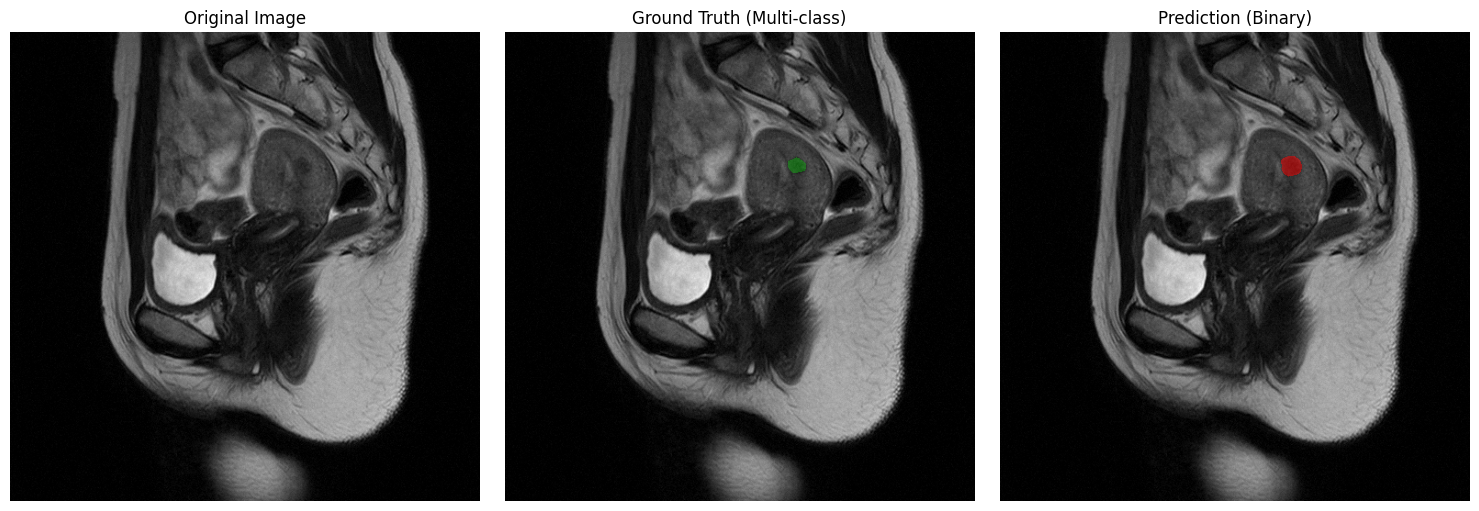


Generating additional visualizations...

Processing rank 1: UMD_221129_278_t2.nii.gz
  Prefix: UMD_221129_278
  Found label: UMD_221129_278_seg_bin.nii.gz
  Loading prediction: UMD_221129_278_pred.nii.gz
  ✓ Saved visualization: top1_result_UMD_221129_278.png

Processing rank 2: UMD_221129_013_t2.nii.gz
  Prefix: UMD_221129_013
  Found label: UMD_221129_013_seg_bin.nii.gz
  Loading prediction: UMD_221129_013_pred.nii.gz
  ✓ Saved visualization: top2_result_UMD_221129_013.png

Processing rank 3: UMD_221129_143_t2.nii.gz
  Prefix: UMD_221129_143
  Found label: UMD_221129_143_seg_bin.nii.gz
  Loading prediction: UMD_221129_143_pred.nii.gz
  ✓ Saved visualization: top3_result_UMD_221129_143.png

Processing rank 4: UMD_221129_006_t2.nii.gz
  Prefix: UMD_221129_006
  Found label: UMD_221129_006_seg_bin.nii.gz
  Loading prediction: UMD_221129_006_pred.nii.gz
  ✓ Saved visualization: top4_result_UMD_221129_006.png

Processing rank 5: UMD_221129_083_t2.nii.gz
  Prefix: UMD_221129_083
  Found l

In [ ]:
# ============================================
# Cell 6: Visualization of Sample Results (FIXED)
# ============================================
import re
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os

def extract_prefix(filename):
    """
    Extract the prefix of a filename (including the name and numbers).

    Example:
    'UMD_221129_001_t2.nii.gz' -> 'UMD_221129_001'
    'UMD_221129_001_seg_bin.nii.gz' -> 'UMD_221129_001'
    """
    # Remove the .nii.gz extension
    base_name = filename.replace('.nii.gz', '')

    # Method 1: Match the pattern "letters_digits_digits"
    pattern = r'^([A-Za-z]+_\d+_\d+)'
    match = re.match(pattern, base_name)
    if match:
        return match.group(1)

    # Method 2: If the filename contains suffixes such as _seg_bin or _t2, extract the preceding part
    parts = base_name.split('_')
    if len(parts) >= 3:
        # Try reconstructing the first three parts
        potential_prefix = '_'.join(parts[:3])
        # Check whether it matches the format "letters_digits_digits"
        if re.match(r'^[A-Za-z]+_\d+_\d+$', potential_prefix):
            return potential_prefix

    # Method 3: Fallback option - return the part after removing known suffixes
    known_suffixes = ['_t2', '_seg_bin', '_seg', '_label', '_mask']
    for suffix in known_suffixes:
        if suffix in base_name:
            return base_name.split(suffix)[0]

    return None

def find_label_file(img_name, labels_path):
    """
    Find the corresponding label file based on the image filename.
    """
    img_prefix = extract_prefix(img_name)

    if img_prefix is None:
        return None

    # First, try using the exact same filename
    if os.path.exists(os.path.join(labels_path, img_name)):
        return img_name

    # Search for a label file with the same prefix
    for potential_label in os.listdir(labels_path):
        label_prefix = extract_prefix(potential_label)
        if label_prefix == img_prefix:
            return potential_label

    # Try other possible naming conventions
    alternative_names = [
        img_name.replace('.nii.gz', '_label.nii.gz'),
        img_name.replace('_t2.nii.gz', '_seg_bin.nii.gz'),
        img_name.replace('_t2.nii.gz', '_seg.nii.gz'),
        f'{img_prefix}_seg_bin.nii.gz',
        f'{img_prefix}_seg.nii.gz',
        f'{img_prefix}_label.nii.gz',
    ]

    for alt_name in alternative_names:
        if os.path.exists(os.path.join(labels_path, alt_name)):
            return alt_name

    return None

def to_scalar(x):
    """
    Convert a list / ndarray / scalar into a unified float value.
    - If x is an iterable object, first safely convert each element to float,
      then compute the mean value.
    - If x is a string scalar, also convert it to float first.
    """
    # Single string or numeric value
    if isinstance(x, (str, bytes)):
        return float(x)

    # List, tuple, ndarray
    if isinstance(x, (list, tuple, np.ndarray)):
        # Convert each element to float, then compute the mean
        return float(np.mean([float(v) for v in x]))

    # Already a numeric value
    return float(x)

# Visualize a sample result
if seg_info['image_name']:
    # Select the case with best mDice score for visualization
    best_idx = np.argmax(seg_info['mDice'])
    best_image = seg_info['image_name'][best_idx]

    # Extract file name prefix
    best_image_prefix = extract_prefix(best_image)

    miou  = to_scalar(seg_info['mIoU'][best_idx])
    aiou  = to_scalar(seg_info['aIoU'][best_idx])
    mdice = to_scalar(seg_info['mDice'][best_idx])
    adice = to_scalar(seg_info['aDice'][best_idx])

    print(f"Best case: {best_image}")
    print(f"Prefix: {best_image_prefix}")
    print(f"mIoU: {miou:.4f}")
    print(f"aIoU: {aiou:.4f}")
    print(f"mDice: {mdice:.4f}")
    print(f"aDice: {adice:.4f}")

    # Load image, label, and prediction
    img_path = os.path.join(imgs_path, best_image)

    # Find the corresponding tag file
    label_filename = find_label_file(best_image, labels_path)
    if label_filename is None:
        print(f"Warning: Cannot find label for {best_image}")
        label_path = os.path.join(labels_path, best_image)  # fallback
    else:
        label_path = os.path.join(labels_path, label_filename)
        print(f"Found label: {label_filename}")

    # Use prefixes to construct predicted filenames
    pred_filename = f"{best_image_prefix}_pred.nii.gz"
    pred_path = os.path.join(predictions_dir, pred_filename)

    print(f"Loading prediction: {pred_filename}")

    try:
        nii_image = sitk.ReadImage(img_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)
        nii_label = sitk.ReadImage(label_path)
        nii_label_data = sitk.GetArrayFromImage(nii_label)

        # Retain the original multi-category labels for visualization.
        nii_label_data_original = nii_label_data.copy()

        # To calculate overlap, a binary version is created.
        nii_label_data_binary = nii_label_data.copy()
        nii_label_data_binary[nii_label_data_binary > 0] = 1

        nii_pred = sitk.ReadImage(pred_path)
        nii_pred_data = sitk.GetArrayFromImage(nii_pred)

        # Find slice with maximum overlap
        overlap = np.logical_and(nii_label_data_binary > 0, nii_pred_data > 0)
        overlap_per_slice = np.sum(overlap, axis=(1, 2))

        if overlap_per_slice.sum() > 0:
            key_slice = np.argmax(overlap_per_slice)
        else:
            # If there is no overlap, use the slice with the largest label.
            label_per_slice = np.sum(nii_label_data_binary > 0, axis=(1, 2))
            key_slice = np.argmax(label_per_slice)

        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Normalize image for display
        img_slice = nii_image_data[key_slice]
        img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)

        # Original image
        axes[0].imshow(img_slice, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        # Ground truth (displaying multi-class labels)
        axes[1].imshow(img_slice, cmap='gray')
        # Use different colors for different blood vessel categories
        unique_labels = np.unique(nii_label_data_original[key_slice])
        unique_labels = unique_labels[unique_labels > 0]
        for label_val in unique_labels:
            # Assign a different color to each category
            if label_val == 1:
                color = np.array([0, 1, 0])  # Green
            elif label_val == 2:
                color = np.array([0, 0, 1])  # Blue
            else:
                color = np.array([1, 1, 0])  # Yellow
            show_mask(nii_label_data_original[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
        axes[1].set_title('Ground Truth (Multi-class)')
        axes[1].axis('off')

        # Prediction
        axes[2].imshow(img_slice, cmap='gray')
        show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))
        axes[2].set_title('Prediction (Binary)')
        axes[2].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(visualizations_dir, 'best_result_visualization.png'), dpi=150, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Error visualizing best case: {str(e)}")

    # Additional: Save more visualizations (top 5 best examples)
    print("\nGenerating additional visualizations...")
    top5_indices = np.argsort(seg_info['mDice'])[-5:][::-1]  # Sort using mDice

    for rank, idx in enumerate(top5_indices):
        case_name = seg_info['image_name'][idx]
        case_prefix = extract_prefix(case_name)

        case_miou = to_scalar(seg_info['mIoU'][idx])
        case_aiou = to_scalar(seg_info['aIoU'][idx])
        case_mdice = to_scalar(seg_info['mDice'][idx])
        case_adice = to_scalar(seg_info['aDice'][idx])

        print(f"\nProcessing rank {rank+1}: {case_name}")
        print(f"  Prefix: {case_prefix}")

        # Load data
        img_path = os.path.join(imgs_path, case_name)

        # Find the corresponding label file
        label_filename = find_label_file(case_name, labels_path)
        if label_filename is None:
            print(f"  Warning: Cannot find label for {case_name}, skipping...")
            continue
        else:
            label_path = os.path.join(labels_path, label_filename)
            print(f"  Found label: {label_filename}")

        # Construct the prediction filename using a prefix
        pred_filename = f"{case_prefix}_pred.nii.gz"
        pred_path = os.path.join(predictions_dir, pred_filename)
        print(f"  Loading prediction: {pred_filename}")

        try:
            nii_image = sitk.ReadImage(img_path)
            nii_image_data = sitk.GetArrayFromImage(nii_image)
            nii_label = sitk.ReadImage(label_path)
            nii_label_data = sitk.GetArrayFromImage(nii_label)

            # Preserve the original multi-category labels for visualization
            nii_label_data_original = nii_label_data.copy()

            # Create a binary version to calculate overlap
            nii_label_data_binary = nii_label_data.copy()
            nii_label_data_binary[nii_label_data_binary > 0] = 1

            nii_pred = sitk.ReadImage(pred_path)
            nii_pred_data = sitk.GetArrayFromImage(nii_pred)

            # Find the slice with the maximum overlap
            overlap = np.logical_and(nii_label_data_binary > 0, nii_pred_data > 0)
            overlap_per_slice = np.sum(overlap, axis=(1, 2))
            if overlap_per_slice.sum() > 0:
                key_slice = np.argmax(overlap_per_slice)
            else:
                # If there is no overlap, use the slice with the largest label
                label_per_slice = np.sum(nii_label_data_binary > 0, axis=(1, 2))
                key_slice = np.argmax(label_per_slice)

            # Create a visualization
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

            # Normalize the image
            img_slice = nii_image_data[key_slice]
            img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)

            # Displaying images and results
            axes[0].imshow(img_slice, cmap='gray')
            axes[0].set_title('Original')
            axes[0].axis('off')

            axes[1].imshow(img_slice, cmap='gray')
            # Display multiple categories GT
            unique_labels = np.unique(nii_label_data_original[key_slice])
            unique_labels = unique_labels[unique_labels > 0]
            for label_val in unique_labels:
                if label_val == 1:
                    color = np.array([0, 1, 0])
                elif label_val == 2:
                    color = np.array([0, 0, 1])
                else:
                    color = np.array([1, 1, 0])
                show_mask(nii_label_data_original[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
            axes[1].set_title('Ground Truth')
            axes[1].axis('off')

            axes[2].imshow(img_slice, cmap='gray')
            show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))
            axes[2].set_title('Prediction')
            axes[2].axis('off')

            plt.suptitle(f'Rank {rank+1}: {case_name} (mIoU={case_miou:.3f}, mDice={case_mdice:.3f})')
            plt.tight_layout()

            # Save to the visualizations folder, using the prefix as part of the filename.
            save_name = f'top{rank+1}_result_{case_prefix}.png'
            plt.savefig(os.path.join(visualizations_dir, save_name), dpi=150, bbox_inches='tight')
            plt.close()

            print(f"  ✓ Saved visualization: {save_name}")

        except Exception as e:
            print(f"  ✗ Error visualizing {case_name}: {str(e)}")
            continue

    print(f"\nAll results have been saved to Google Drive:")
    print(f"Main directory: {pred_save_dir}")
    print(f"Predictions: {predictions_dir}")
    print(f"Visualizations: {visualizations_dir}")

    # Create a detailed report containing the performance of each category
    if len(all_metrics) > 0 and 'per_class_iou' in all_metrics[0]:
        print("\n" + "="*50)
        print("Per-class performance analysis:")
        print("="*50)

        # Collect all categories
        all_classes = set()
        for m in all_metrics:
            if 'per_class_iou' in m:
                all_classes.update(m['per_class_iou'].keys())

        # Calculate the average performance of each category
        for class_id in sorted(all_classes):
            class_ious = []
            class_dices = []
            for m in all_metrics:
                if 'per_class_iou' in m and class_id in m['per_class_iou']:
                    class_ious.append(m['per_class_iou'][class_id])
                    if 'per_class_dice' in m and class_id in m['per_class_dice']:
                        class_dices.append(m['per_class_dice'][class_id])

            if class_ious:
                print(f"\nClass {class_id}:")
                print(f"  Mean IoU: {np.mean(class_ious):.4f}")
                if class_dices:
                    print(f"  Mean Dice: {np.mean(class_dices):.4f}")
                print(f"  Number of samples: {len(class_ious)}")

    # Final statistics
    print("\n" + "="*50)
    print("Final statistics:")
    print("="*50)
    print(f"Total number of processed images: {len(seg_info['image_name'])}")
    if len(seg_info['image_name']) > 0:
        print(f"Mean mIoU: {np.mean([to_scalar(x) for x in seg_info['mIoU']]):.4f}")
        print(f"Mean aIoU: {np.mean([to_scalar(x) for x in seg_info['aIoU']]):.4f}")
        print(f"Mean mDice: {np.mean([to_scalar(x) for x in seg_info['mDice']]):.4f}")
        print(f"Mean aDice: {np.mean([to_scalar(x) for x in seg_info['aDice']]):.4f}")

        # Handle inf values in HD95
        hd95_values = []
        for x in seg_info['hd95']:
            val = to_scalar(x)
            if not np.isinf(val):
                hd95_values.append(val)

        if hd95_values:
            print(f"Average HD95 (excluding inf): {np.mean(hd95_values):.4f}")
            print(f"Number of inf HD95 values: {len(seg_info['hd95']) - len(hd95_values)}")
else:
    print("No results to visualize.")
    print("Please check if the processing completed successfully.")

In [ ]:
# ============================================
# Cell 7: Image augmentation
# ============================================

# Gamma Correction
# Adjusts the global brightness curve (non-linear transformation), affecting the overall brightness balance of the image (e.g., brightening overly dark lesion areas or darkening overly bright areas).
# Gamma value is set between 0.8 and 1.2 (slight adjustment, without overturning the original brightness distribution).

# Image augmentation Dependency
!pip install nibabel

import os
import numpy as np
import nibabel as nib
from glob import glob
import json
def gamma_correction(image: np.ndarray, gamma: float) -> np.ndarray:
    """
    Apply gamma correction to maintain the original data range
    """
    image = image.astype(np.float32)
    image_min, image_max = image.min(), image.max()

    if image_max > image_min:
        normalized = (image - image_min) / (image_max - image_min)
        corrected = np.power(normalized, gamma)
        corrected = corrected * (image_max - image_min) + image_min
        return corrected
    else:
        return image

def apply_random_gamma_tta(input_folder: str, output_folder: str,
                          gamma_range: tuple = (0.8, 1.2),
                          seed: int = None) -> dict:
    """
    Enhance each image by applying a random gamma value.

    Args:
        input_folder: Input folder path
        output_folder: Output folder path
        gamma_range: Gamma value range
        seed: Random seed (optional)

    Returns:
        gamma_record: Record the gamma value used for each image.
    """
    os.makedirs(output_folder, exist_ok=True)

        # Set random seed (if provided)
    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Gamma range: {gamma_range}")

    # Record the gamma value used for each file
    gamma_record = {}

    for file_path in nii_files:
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        base_filename = os.path.basename(file_path).replace('.nii.gz', '')

        # Randomly generate a gamma value
        gamma = round(np.random.uniform(gamma_range[0], gamma_range[1]), 2)

        # Apply gamma correction
        corrected = gamma_correction(img_data, gamma)

        # Save the augmented image
        # out_filename = f"{base_filename}_gamma{gamma:.2f}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(corrected, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record the gamma value
        gamma_record[base_filename] = {
            'original_file': file_path,
            'output_file': out_filename,
            'gamma': gamma
        }

        print(f"Processed: {base_filename} -> gamma={gamma}")

    # Save the gamma record
    record_path = os.path.join(output_folder, 'gamma_record.json')
    with open(record_path, 'w') as f:
        json.dump(gamma_record, f, indent=2)

    print(f"\nProcessing completed!")
    print(f"Results saved in: {output_folder}")
    print(f"Gamma record saved in: {record_path}")

    # Output gamma statistics
    all_gammas = [info['gamma'] for info in gamma_record.values()]
    print(f"\nGamma statistics:")
    print(f"  Mean: {np.mean(all_gammas):.3f}")
    print(f"  Standard deviation: {np.std(all_gammas):.3f}")
    print(f"  Minimum: {min(all_gammas)}")
    print(f"  Maximum: {max(all_gammas)}")

    return gamma_record

# Contrast Enhancement
# Linearly stretches the grayscale range to amplify intensity differences between lesions and normal tissue, enhancing boundary information (but may also amplify noise).
# Scaling factor in the range 1.1~1.3 (moderate enhancement, without causing pixel saturation)
import os
import numpy as np
import nibabel as nib
from glob import glob
import json

def contrast_enhancement(image, alpha):
    """
    Contrast enhancement: linearly adjust the grayscale range

    Args:
        image: input image
        alpha: contrast factor (>1 increases contrast)

    Returns:
        enhanced image
    """
    image = image.astype(np.float32)
    image_min, image_max = image.min(), image.max()

    # Use the mean value as the center point for contrast adjustment
    mean_val = np.mean(image)

    # Apply contrast enhancement
    enhanced = (image - mean_val) * alpha + mean_val

    # Clip to original range to avoid saturation
    enhanced = np.clip(enhanced, image_min, image_max)

    return enhanced

def apply_contrast_enhancement(input_folder, output_folder, alpha_range=(1.1, 1.3), seed=None):
    """
    Apply random contrast enhancement to each image

    Args:
        input_folder: input folder path
        output_folder: output folder path
        alpha_range: alpha value range
        seed: random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Alpha range: {alpha_range}")

    contrast_record = {}

    for file_path in nii_files:
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        # Get filename
        filename = os.path.basename(file_path)
        base_filename = filename.replace('.nii.gz', '')

        # Randomly select alpha value
        alpha = round(np.random.uniform(alpha_range[0], alpha_range[1]), 2)

        # Apply contrast enhancement
        enhanced = contrast_enhancement(img_data, alpha)

        # Check enhancement effect
        original_std = np.std(img_data)
        enhanced_std = np.std(enhanced)
        actual_enhancement = (enhanced_std / original_std - 1) * 100

        # Save the enhanced image
        # out_filename = f"{base_filename}_contrast{alpha:.2f}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(enhanced, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record information
        contrast_record[base_filename] = {
            'original_file': filename,
            'output_file': out_filename,
            'alpha': alpha,
            'actual_enhancement': f"{actual_enhancement:.1f}%"
        }

        print(f"Processed: {base_filename} -> alpha={alpha}, actual enhancement={actual_enhancement:.1f}%")

    # Save record
    record_path = os.path.join(output_folder, 'contrast_record.json')
    with open(record_path, 'w') as f:
        json.dump(contrast_record, f, indent=2)

    print(f"\nContrast enhancement complete!")
    print(f"Results saved in: {output_folder}")
    print(f"Contrast record: {record_path}")

    # Statistics
    all_alphas = [info['alpha'] for info in contrast_record.values()]
    print(f"\nAlpha statistics:")
    print(f"  Mean: {np.mean(all_alphas):.3f}")
    print(f"  Std dev: {np.std(all_alphas):.3f}")
    print(f"  Min: {min(all_alphas)}")
    print(f"  Max: {max(all_alphas)}")

    return contrast_record

# Gaussian Blur
# Smooths image details (spatial-domain filtering), primarily affecting high-frequency information (e.g., sharpness of lesion boundaries), simulating scenarios of insufficient image resolution.
# Sigma in the range 0.5~1.5 (slight smoothing, without blurring lesions out of existence)
import os
import numpy as np
import nibabel as nib
from glob import glob
import json
from scipy.ndimage import gaussian_filter

def gaussian_blur_3d(image, sigma):
    """
    3D Gaussian blur, tailored for medical image characteristics

    Args:
        image: 3D medical image
        sigma: standard deviation of the Gaussian kernel (scalar or 3-tuple)

    Returns:
        blurred image
    """
    image = image.astype(np.float32)

    # If sigma is a scalar, apply to all dimensions;
    # if a tuple, apply to each dimension separately
    blurred = gaussian_filter(image, sigma=sigma, mode='reflect')

    return blurred

def apply_gaussian_blur(input_folder, output_folder,
                                  sigma_range=(0.5, 1.5), seed=None):
    """
    Apply random Gaussian blur to each image (simplified version)

    Args:
        input_folder: input folder path
        output_folder: output folder path
        sigma_range: sigma value range
        seed: random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Sigma range: {sigma_range}")

    blur_record = {}

    for file_path in nii_files:
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        # Get filename
        filename = os.path.basename(file_path)
        base_filename = filename.replace('.nii.gz', '')

        # Randomly select sigma value
        sigma = round(np.random.uniform(sigma_range[0], sigma_range[1]), 2)

        # Apply Gaussian blur
        blurred = gaussian_blur_3d(img_data, sigma)

        # Calculate blur effect (reduction in edge intensity)
        original_edges = np.std(np.gradient(img_data, axis=0))
        blurred_edges = np.std(np.gradient(blurred, axis=0))
        edge_reduction = (1 - blurred_edges / original_edges) * 100

        # Save the blurred image
        # out_filename = f"{base_filename}_blur{sigma:.2f}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(blurred, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record information
        blur_record[base_filename] = {
            'original_file': filename,
            'output_file': out_filename,
            'sigma': sigma,
            'edge_reduction': f"{edge_reduction:.1f}%",
            'image_shape': img_data.shape
        }

        print(f"Processed: {base_filename} -> sigma={sigma}, edge reduction={edge_reduction:.1f}%")

    # Save record
    record_path = os.path.join(output_folder, 'blur_record.json')
    with open(record_path, 'w') as f:
        json.dump(blur_record, f, indent=2)

    print(f"\nGaussian blur complete!")
    print(f"Results saved in: {output_folder}")
    print(f"Blur record: {record_path}")

    # Statistics
    all_sigmas = [info['sigma'] for info in blur_record.values()]
    print(f"\nSigma statistics:")
    print(f"  Mean: {np.mean(all_sigmas):.3f}")
    print(f"  Std dev: {np.std(all_sigmas):.3f}")
    print(f"  Min: {min(all_sigmas)}")
    print(f"  Max: {max(all_sigmas)}")

    return blur_record

def apply_gaussian_blur_tta(input_folder, output_folder,
                          sigma_values=None, seed=42):
    """
    Gaussian blur augmentation based on TTA theory (full version)

    Args:
        input_folder: input folder
        output_folder: output folder
        sigma_values: fixed list of sigma values
        seed: random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    # Use a fixed set of sigma values (including identity transform)
    if sigma_values is None:
        sigma_values = [0.0, 0.5, 0.75, 1.0, 1.25, 1.5]  # 0 = no blur

    # Get file list
    image_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(image_files)} image files")
    print(f"Using sigma values: {sigma_values}")

    # Calculate theoretical weights
    weights = calculate_blur_weights(sigma_values)

    arg_info = {
        'augmentation_type': 'gaussian_blur',
        'sigma_values': sigma_values,
        'theoretical_weights': weights.tolist(),
        'processed_files': {}
    }

    for image_path in image_files:
        filename = os.path.basename(image_path)
        base_name = filename.replace('.nii.gz', '')

        # Load image
        img_obj = nib.load(image_path)
        img_data = img_obj.get_fdata()

        augmented_files = []

        for i, sigma in enumerate(sigma_values):
            # Apply Gaussian blur
            if sigma == 0:
                blurred = img_data  # identity transform
            else:
                blurred = gaussian_blur_3d(img_data, sigma)

            # Save
            out_filename = f"{base_name}_blur{sigma:.1f}.nii.gz"
            out_path = os.path.join(output_folder, out_filename)

            out_nifti = nib.Nifti1Image(blurred, affine=img_obj.affine,
                                       header=img_obj.header)
            nib.save(out_nifti, out_path)

            augmented_files.append({
                'filename': out_filename,
                'sigma': sigma,
                'weight': weights[i]
            })

        arg_info['processed_files'][base_name] = {
            'original_file': filename,
            'augmented_files': augmented_files
        }

        print(f"Processed: {filename} -> generated {len(sigma_values)} blurred versions")

    # Save augmentation info
    info_path = os.path.join(output_folder, 'gaussian_blur_info.json')
    with open(info_path, 'w') as f:
        json.dump(arg_info, f, indent=2)

    print(f"\nProcessing complete!")
    print(f"Theoretical weights: {weights}")

    return arg_info

def calculate_blur_weights(sigma_values):
    """
    Calculate theoretical weights for Gaussian blur.
    No blur (sigma=0) gets the highest weight; higher blur gets lower weight.
    """
    sigma_array = np.array(sigma_values)

    # Weights are inversely proportional to sigma (less blur = higher weight)
    weights = 1.0 / (1.0 + sigma_array)

    # Normalize
    weights = weights / weights.sum()

    return weights


# Gaussian Noise Injection
# Adds random pixel perturbations (additive noise) to simulate device noise or scan artifacts, testing the model's robustness to noisy data.
# Noise intensity is 5%~10% of the original image standard deviation (weak noise, does not obscure lesions)
import os
import numpy as np
import nibabel as nib
from glob import glob
import json

def add_gaussian_noise(image, noise_ratio, seed=None):
    """
    Add Gaussian noise

    Args:
        image: input image
        noise_ratio: noise level relative to image standard deviation
        seed: random seed for reproducibility

    Returns:
        noisy image
    """
    image = image.astype(np.float32)
    image_min, image_max = image.min(), image.max()

    # Set random seed
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random.RandomState()

    # Calculate noise standard deviation
    image_std = np.std(image)
    noise_std = image_std * noise_ratio

    # Generate Gaussian noise
    noise = rng.normal(0, noise_std, image.shape)

    # Add noise
    noisy_image = image + noise

    # Clip to original range
    noisy_image = np.clip(noisy_image, image_min, image_max)

    return noisy_image

def apply_gaussian_noise(input_folder, output_folder,
                                   ratio_range=(0.05, 0.1), seed=None):
    """
    Apply Gaussian noise augmentation to each image

    Args:
        input_folder: input folder path
        output_folder: output folder path
        ratio_range: noise ratio range
        seed: master random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Noise type: 100% Gaussian noise")
    print(f"Noise ratio range: {ratio_range}")

    noise_record = {}

    for idx, file_path in enumerate(nii_files):
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        # Get filename
        filename = os.path.basename(file_path)
        base_filename = filename.replace('.nii.gz', '')

        # Randomly select noise ratio
        noise_ratio = round(np.random.uniform(ratio_range[0], ratio_range[1]), 3)

        # Generate a unique seed for each image
        image_seed = seed + idx if seed is not None else None

        # Apply Gaussian noise
        noisy_image = add_gaussian_noise(img_data, noise_ratio, seed=image_seed)

        # Calculate SNR change
        original_mean = np.mean(img_data)
        original_std = np.std(img_data)
        noisy_mean = np.mean(noisy_image)
        noisy_std = np.std(noisy_image)

        original_snr = original_mean / original_std if original_std > 0 else 0
        noisy_snr = noisy_mean / noisy_std if noisy_std > 0 else 0
        snr_reduction = (1 - noisy_snr / original_snr) * 100 if original_snr > 0 else 0

        # Save the noisy image
        # out_filename = f"{base_filename}_noise{int(noise_ratio*1000):03d}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(noisy_image, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record information
        noise_record[base_filename] = {
            'original_file': filename,
            'output_file': out_filename,
            'noise_ratio': noise_ratio,
            'noise_percentage': f"{noise_ratio*100:.1f}%",
            'noise_type': 'gaussian',
            'snr_reduction': f"{snr_reduction:.1f}%",
            'seed': image_seed
        }

        print(f"Processed: {base_filename} -> noise ratio={noise_ratio:.3f} ({noise_ratio*100:.1f}%), SNR reduction={snr_reduction:.1f}%")

    # Save record
    record_path = os.path.join(output_folder, 'gaussian_noise_record.json')
    with open(record_path, 'w') as f:
        json.dump(noise_record, f, indent=2)

    print(f"\nGaussian noise injection complete!")
    print(f"Results saved in: {output_folder}")
    print(f"Noise record: {record_path}")

    # Statistics
    all_ratios = [info['noise_ratio'] for info in noise_record.values()]
    print(f"\nNoise ratio statistics:")
    print(f"  Mean: {np.mean(all_ratios):.3f} ({np.mean(all_ratios)*100:.1f}%)")
    print(f"  Std dev: {np.std(all_ratios):.3f}")
    print(f"  Min: {min(all_ratios):.3f} ({min(all_ratios)*100:.1f}%)")
    print(f"  Max: {max(all_ratios):.3f} ({max(all_ratios)*100:.1f}%)")

    # Analyze noise effect
    snr_reductions = []
    for info in noise_record.values():
        snr_red = float(info['snr_reduction'].replace('%', ''))
        snr_reductions.append(snr_red)

    print(f"\nSNR reduction statistics:")
    print(f"  Mean SNR reduction: {np.mean(snr_reductions):.1f}%")
    print(f"  Max SNR reduction: {max(snr_reductions):.1f}%")
    print(f"  Min SNR reduction: {min(snr_reductions):.1f}%")

    return noise_record


In [ ]:
# ============================================
# Cell 7.1: Apply Image augmentation
# ============================================
# Import necessary modules
from datetime import datetime
import os

timestamp = datetime.now().strftime("%m%d")

input_folder = '/content/drive/MyDrive/SegTTA/dataset/UMD/images'
result_path = '/content/drive/MyDrive/SegTTA/results/UMD'


# Gamma correction
output_folder = os.path.join(result_path, f'augmentation_gamma_correction_{timestamp}')
gamma_record = apply_random_gamma_tta(
  input_folder=input_folder,
  output_folder=output_folder,
  gamma_range=(0.8, 1.2),
  seed=None
)

# Contrast enhancement
output_folder = os.path.join(result_path, f'augmentation_contrast_enhancement_{timestamp}')
contrast_record = apply_contrast_enhancement(
  input_folder=input_folder,
  output_folder=output_folder,
  alpha_range=(1.1, 1.3),
  seed=None
)

# Gaussian blur
output_folder = os.path.join(result_path, f'augmentation_gaussian_blur_{timestamp}')
blur_record = apply_gaussian_blur(
  input_folder=input_folder,
  output_folder=output_folder,
  sigma_range=(0.5, 1.5),
  seed=None
)

# Gaussian noise
output_folder = os.path.join(result_path, f'augmentation_noise_{timestamp}')
noise_record = apply_gaussian_noise(
  input_folder=input_folder,
  output_folder=output_folder,
  ratio_range=(0.05, 0.1),
  seed=None
)

找到 300 个图像文件
Gamma范围: (0.8, 1.2)
处理: UMD_221129_001_t2 -> gamma=0.94
处理: UMD_221129_002_t2 -> gamma=0.89
处理: UMD_221129_003_t2 -> gamma=0.83
处理: UMD_221129_004_t2 -> gamma=1.09
处理: UMD_221129_005_t2 -> gamma=0.86
处理: UMD_221129_006_t2 -> gamma=0.96
处理: UMD_221129_007_t2 -> gamma=1.1
处理: UMD_221129_008_t2 -> gamma=0.87
处理: UMD_221129_009_t2 -> gamma=0.89
处理: UMD_221129_010_t2 -> gamma=1.04
处理: UMD_221129_011_t2 -> gamma=0.98
处理: UMD_221129_012_t2 -> gamma=1.07
处理: UMD_221129_013_t2 -> gamma=0.95
处理: UMD_221129_014_t2 -> gamma=1.19
处理: UMD_221129_015_t2 -> gamma=0.88
处理: UMD_221129_016_t2 -> gamma=1.18
处理: UMD_221129_017_t2 -> gamma=0.87
处理: UMD_221129_018_t2 -> gamma=1.06
处理: UMD_221129_019_t2 -> gamma=1.02
处理: UMD_221129_020_t2 -> gamma=0.91
处理: UMD_221129_021_t2 -> gamma=1.12
处理: UMD_221129_022_t2 -> gamma=0.96
处理: UMD_221129_023_t2 -> gamma=0.82
处理: UMD_221129_024_t2 -> gamma=1.09
处理: UMD_221129_025_t2 -> gamma=0.97
处理: UMD_221129_026_t2 -> gamma=1.03
处理: UMD_221129_027_t2 -> gamma=1

In [ ]:
# ============================================
# Cell 8: Voting (revised)
# ============================================
import numpy as np
import SimpleITK as sitk
from glob import glob
import os
import json
import pickle
import re
from datetime import datetime
import pandas as pd

def extract_prefix(filename):
    """Extract filename prefix"""
    base_name = filename.replace('.nii.gz', '')
    match = re.match(r'^([A-Za-z]+_\d+_\d+)', base_name)
    if match:
        return match.group(1)
    # Fallback
    for suffix in ['_t2', '_seg_bin', '_seg', '_label', '_mask', '_pred']:
        if suffix in base_name:
            return base_name.split(suffix)[0]
    return base_name

def load_predictions_with_confidence(pred_dirs, image_name):
    """
    Load prediction results and confidence maps for all augmented versions

    Args:
        pred_dirs: list of 4 prediction result folders
        image_name: original image name

    Returns:
        predictions: list of arrays (binary masks)
        confidences: list of arrays (confidence maps)
    """
    predictions = []
    confidences = []

    # Extract prefix for locating prediction files
    prefix = extract_prefix(image_name)

    for pred_dir in pred_dirs:
        # Build prediction filename using prefix
        pred_filename = f'{prefix}_pred.nii.gz'
        pred_path = os.path.join(pred_dir, 'predictions', pred_filename)

        # If file does not exist, try other possible formats
        if not os.path.exists(pred_path):
            # Try original naming method
            alt_path = os.path.join(pred_dir, 'predictions',
                                   image_name.replace('.nii.gz', '_pred.nii.gz'))
            if os.path.exists(alt_path):
                pred_path = alt_path
            else:
                print(f"Warning: prediction file {pred_filename} not found in {os.path.basename(pred_dir)}")
                # Skip this prediction
                continue

        try:
            # Load prediction mask
            pred_img = sitk.ReadImage(pred_path)
            pred_data = sitk.GetArrayFromImage(pred_img)
            predictions.append(pred_data)

            # Also load confidence map if it was saved
            conf_path = pred_path.replace('_pred.nii.gz', '_conf.nii.gz')
            if os.path.exists(conf_path):
                conf_img = sitk.ReadImage(conf_path)
                conf_data = sitk.GetArrayFromImage(conf_img)
            else:
                # If no confidence map, use binary mask as confidence (0 or 1)
                conf_data = pred_data.astype(float)

            confidences.append(conf_data)
            print(f"  ✓ Loaded: {os.path.basename(pred_path)}")

        except Exception as e:
            print(f"  ✗ Failed to read {pred_path}: {e}")

    return predictions, confidences

def enhanced_voting_fusion(predictions, confidences=None, voting_method='soft_voting'):
    """
    Enhanced voting fusion method

    Args:
        predictions: list of binary masks (n_models, D, H, W)
        confidences: list of confidence maps (optional)
        voting_method: voting strategy

    Returns:
        fused_confidence: fused confidence map (range [0,1])
    """
    predictions = np.array(predictions)
    n_models = predictions.shape[0]

    if voting_method == 'soft_voting':
        # Soft voting: simple average, yielding 0, 0.25, 0.5, 0.75, 1.0
        fused_confidence = np.mean(predictions, axis=0)

    elif voting_method == 'weighted_voting':
        # Weighted voting: assign different weights to different models
        # e.g., higher weight for better-performing augmentation methods
        weights = np.array([0.4, 0.4, 0.6, 0.6])[:n_models]  # ensure weights match number of models
        weights = weights / weights.sum()

        weighted_sum = np.zeros_like(predictions[0], dtype=float)
        for i, (pred, w) in enumerate(zip(predictions, weights)):
            weighted_sum += pred * w
        fused_confidence = weighted_sum

    elif voting_method == 'threshold_voting':
        # Threshold voting: compute vote ratio
        vote_count = np.sum(predictions, axis=0)
        fused_confidence = vote_count / n_models
    else:
        # Default: use soft voting
        fused_confidence = np.mean(predictions, axis=0)

    # Verify output range
    print(f"Fused confidence range: [{fused_confidence.min():.3f}, {fused_confidence.max():.3f}]")
    unique_values = np.unique(fused_confidence)
    if len(unique_values) < 10:
        print(f"Unique values: {unique_values}")

    return fused_confidence

def apply_threshold(confidence_map, threshold=0.5):
    """
    Apply threshold to generate binary mask

    Args:
        confidence_map: confidence map
        threshold: binarization threshold

    Returns:
        binary_mask: binary segmentation result
    """
    return (confidence_map >= threshold).astype(np.uint8)

def save_fusion_results(fusion_results, output_dir, augmentation_names, voting_method, threshold):
    """
    Save fusion results to multiple file formats

    Args:
        fusion_results: list of fusion results
        output_dir: output directory
        augmentation_names: names of augmentation methods used
        voting_method: voting strategy
        threshold: threshold applied
    """
    # Create results directory
    results_dir = os.path.join(output_dir, 'fusion_results')
    os.makedirs(results_dir, exist_ok=True)

    # 1. Save basic statistics to JSON
    summary = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'num_images': len(fusion_results),
        'augmentation_methods': augmentation_names,
        'voting_method': voting_method,
        'threshold': threshold,
        'images_processed': [r['image'] for r in fusion_results]
    }

    # Calculate confidence statistics
    confidence_stats = []
    for result in fusion_results:
        conf_map = result['fused_confidence']
        final_mask = result['final_mask']

        stats = {
            'image': result['image'],
            'confidence_mean': float(np.mean(conf_map)),
            'confidence_std': float(np.std(conf_map)),
            'confidence_min': float(np.min(conf_map)),
            'confidence_max': float(np.max(conf_map)),
            'foreground_pixels': int(np.sum(final_mask)),
            'foreground_percentage': float(np.sum(final_mask) / final_mask.size * 100)
        }
        confidence_stats.append(stats)

    summary['confidence_statistics'] = confidence_stats

    # Save JSON
    json_path = os.path.join(results_dir, f'fusion_summary_threshold_{threshold:.2f}.json')
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=4)

    # 2. Save detailed statistics to CSV
    df = pd.DataFrame(confidence_stats)
    csv_path = os.path.join(results_dir, f'fusion_statistics_threshold_{threshold:.2f}.csv')
    df.to_csv(csv_path, index=False)

    # 3. Save complete results to pickle (including numpy arrays)
    pickle_path = os.path.join(results_dir, f'fusion_results_complete_threshold_{threshold:.2f}.pkl')
    # Save only essential info to avoid large files
    results_to_save = []
    for result in fusion_results:
        results_to_save.append({
            'image': result['image'],
            'confidence_map_shape': result['fused_confidence'].shape,
            'final_mask_shape': result['final_mask'].shape,
            # Optionally save the full arrays
            # 'fused_confidence': result['fused_confidence'],
            # 'final_mask': result['final_mask']
        })

    with open(pickle_path, 'wb') as f:
        pickle.dump({
            'summary': summary,
            'results': results_to_save,
            'full_results_available': False  # flag: whether full arrays are included
        }, f)

    # 4. Generate summary report
    report_path = os.path.join(results_dir, f'fusion_report_threshold_{threshold:.2f}.txt')
    with open(report_path, 'w') as f:
        f.write("TTA Fusion Results Report\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Generated at: {summary['timestamp']}\n")
        f.write(f"Number of images processed: {summary['num_images']}\n")
        f.write(f"Augmentation methods: {', '.join(augmentation_names)}\n")
        f.write(f"Voting method: {voting_method}\n")
        f.write(f"Threshold: {threshold}\n\n")

        f.write("Confidence Statistics Summary:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Average confidence mean: {df['confidence_mean'].mean():.3f}\n")
        f.write(f"Average foreground percentage: {df['foreground_percentage'].mean():.1f}%\n")
        f.write(f"Min foreground pixels: {df['foreground_pixels'].min()}\n")
        f.write(f"Max foreground pixels: {df['foreground_pixels'].max()}\n\n")

        f.write("Per-image Results:\n")
        f.write("-" * 40 + "\n")
        for _, row in df.iterrows():
            f.write(f"{row['image']}: "
                   f"conf_mean={row['confidence_mean']:.3f}, "
                   f"foreground={row['foreground_percentage']:.1f}%\n")

    print(f"\nFusion results saved to:")
    print(f"  - Summary JSON: {json_path}")
    print(f"  - Statistics CSV: {csv_path}")
    print(f"  - Complete results: {pickle_path}")
    print(f"  - Report: {report_path}")

    return {
        'json_path': json_path,
        'csv_path': csv_path,
        'pickle_path': pickle_path,
        'report_path': report_path
    }

def tta_fusion_pipeline(image_files, augmentation_dirs, output_dir,
                       voting_method='weighted_voting', threshold=0.5):
    """
    Full TTA fusion pipeline

    Args:
        image_files: list of original image files
        augmentation_dirs: 4 augmentation result folders
        output_dir: output folder
        voting_method: voting strategy
        threshold: binarization threshold
    """
    os.makedirs(output_dir, exist_ok=True)

    # Create subfolders for different threshold values
    threshold_dir = os.path.join(output_dir, f'threshold_{threshold:.2f}')
    os.makedirs(threshold_dir, exist_ok=True)

    # Create predictions subdirectory (consistent structure with other results)
    predictions_dir = os.path.join(output_dir, 'predictions')
    os.makedirs(predictions_dir, exist_ok=True)

    fusion_results = []

    # Extract augmentation method names
    augmentation_names = []
    for dir_path in augmentation_dirs:
        # Extract augmentation method from directory name
        dir_name = os.path.basename(dir_path)
        if 'gamma' in dir_name:
            augmentation_names.append('gamma_correction')
        elif 'contrast' in dir_name:
            augmentation_names.append('contrast_enhancement')
        elif 'blur' in dir_name:
            augmentation_names.append('gaussian_blur')
        elif 'noise' in dir_name:
            augmentation_names.append('gaussian_noise')
        else:
            augmentation_names.append(dir_name)

    # Process each image
    for img_file in image_files:
        img_name = os.path.basename(img_file)
        prefix = extract_prefix(img_name)

        # 1. Load 4 prediction results
        predictions, confidences = load_predictions_with_confidence(
            augmentation_dirs, img_name
        )

        # Check if there are enough predictions
        if len(predictions) < 2:
            print(f"⚠ Skipping {img_name}: only found {len(predictions)} predictions")
            continue

        # 2. Confidence voting fusion - using enhanced_voting_fusion
        print(f"\nProcessing {img_name} - voting method: {voting_method}")
        print(f"  Found {len(predictions)} predictions to fuse")
        fused_confidence = enhanced_voting_fusion(
            predictions, confidences, voting_method
        )

        # Show vote distribution for threshold_voting
        if voting_method == 'threshold_voting':
            vote_count = np.sum(predictions, axis=0)
            print(f"Vote distribution:")
            for i in range(len(predictions) + 1):
                pixels = np.sum(vote_count == i)
                if pixels > 0:
                    print(f"  {i} votes: {pixels} pixels ({pixels/vote_count.size*100:.2f}%)")

        # 3. Apply threshold
        final_mask = apply_threshold(fused_confidence, threshold)
        print(f"After threshold {threshold}: foreground pixels = {np.sum(final_mask)} ({np.sum(final_mask)/final_mask.size*100:.2f}%)")

        # 4. Save results
        # Save fused confidence map (in threshold subdirectory)
        conf_save_path = os.path.join(threshold_dir,
                                     f'{prefix}_fused_conf.nii.gz')
        # Save final binary mask (in threshold subdirectory)
        mask_save_path = os.path.join(threshold_dir,
                                     f'{prefix}_fused_mask.nii.gz')

        # Also save a copy in the predictions directory (standard naming)
        pred_save_path = os.path.join(predictions_dir,
                                     f'{prefix}_pred.nii.gz')

        # Need metadata from original image for saving
        orig_img = sitk.ReadImage(img_file)

        conf_img = sitk.GetImageFromArray(fused_confidence)
        conf_img.CopyInformation(orig_img)
        sitk.WriteImage(conf_img, conf_save_path)

        mask_img = sitk.GetImageFromArray(final_mask)
        mask_img.CopyInformation(orig_img)
        sitk.WriteImage(mask_img, mask_save_path)

        # Also save to predictions directory
        sitk.WriteImage(mask_img, pred_save_path)

        fusion_results.append({
            'image': img_name,
            'fused_confidence': fused_confidence,
            'final_mask': final_mask
        })

        print(f"Finished processing: {img_name}")

    # Save fusion results to files
    if fusion_results:
        saved_files = save_fusion_results(
            fusion_results,
            output_dir,
            augmentation_names,
            voting_method,
            threshold
        )
    else:
        print("Warning: no images were successfully processed")
        saved_files = {}

    print(f"\nTTA fusion complete, processed {len(fusion_results)} images")
    print(f"Results saved in: {output_dir}")

    return fusion_results, saved_files

In [ ]:
# ============================================
# Cell 8.1: Execute Voting (revised)
# ============================================
from datetime import datetime
from glob import glob
import os

# Set paths
dataset_path = '/content/drive/MyDrive/SegTTA/dataset/UMD'
result_path = '/content/drive/MyDrive/SegTTA/results/UMD'

# 4 augmentation result folders

augmentation_dirs = [
    os.path.join(result_path, 'MedSAM2_results_US_Heart_augmentation_contrast_enhancement_0905'),
    os.path.join(result_path, 'MedSAM2_results_US_Heart_augmentation_gamma_correction_0905'),
    os.path.join(result_path, 'MedSAM2_results_US_Heart_augmentation_gaussian_blur_0905'),
    os.path.join(result_path, 'MedSAM2_results_US_Heart_augmentation_noise_0905')
]

# Original images
image_files = sorted(glob(os.path.join(dataset_path, 'images', '*.nii.gz')))
if len(image_files) == 0:  # if images directory does not exist, try imgs
    image_files = sorted(glob(os.path.join(dataset_path, 'imgs', '*.nii.gz')))

# Output directory
timestamp = datetime.now().strftime("%m%d")
output_dir = os.path.join(result_path, f'MedSAM2_TTA_ablation_study_threshold0.9_{timestamp}')

# Run fusion
threshold = 0.9
voting_method = 'weighted_voting'

print("Starting TTA fusion...")
print(f"Voting method: {voting_method}")
print(f"Threshold: {threshold}")

results = tta_fusion_pipeline(
    image_files=image_files,
    augmentation_dirs=augmentation_dirs,
    output_dir=output_dir,
    voting_method=voting_method,
    threshold=threshold
)

print("\nProcessing complete!")

开始TTA融合处理...
投票方法: weighted_voting
阈值: 0.9
  ✓ 加载: UMD_221129_001_pred.nii.gz
  ✓ 加载: UMD_221129_001_pred.nii.gz
  ✓ 加载: UMD_221129_001_pred.nii.gz
  ✓ 加载: UMD_221129_001_pred.nii.gz

处理 UMD_221129_001_t2.nii.gz - 使用投票方法: weighted_voting
  找到 4 个预测进行融合
融合置信度范围: [0.000, 1.000]
唯一值: [0.  0.2 0.3 0.4 0.5 0.6 0.7 0.8 1. ]
应用阈值 0.9 后，前景像素: 45101 (0.50%)
完成处理: UMD_221129_001_t2.nii.gz
  ✓ 加载: UMD_221129_002_pred.nii.gz
  ✓ 加载: UMD_221129_002_pred.nii.gz
  ✓ 加载: UMD_221129_002_pred.nii.gz
  ✓ 加载: UMD_221129_002_pred.nii.gz

处理 UMD_221129_002_t2.nii.gz - 使用投票方法: weighted_voting
  找到 4 个预测进行融合
融合置信度范围: [0.000, 1.000]
唯一值: [0.  0.2 0.3 0.4 0.5 0.6 0.7 0.8 1. ]
应用阈值 0.9 后，前景像素: 6677 (0.11%)
完成处理: UMD_221129_002_t2.nii.gz
  ✓ 加载: UMD_221129_003_pred.nii.gz
  ✓ 加载: UMD_221129_003_pred.nii.gz
  ✓ 加载: UMD_221129_003_pred.nii.gz
  ✓ 加载: UMD_221129_003_pred.nii.gz

处理 UMD_221129_003_t2.nii.gz - 使用投票方法: weighted_voting
  找到 4 个预测进行融合
融合置信度范围: [0.000, 1.000]
唯一值: [0.  0.2 0.3 0.4 0.5 0.6 0.7 0.8 1. ]
应用阈

In [ ]:
# ============================================
# Cell 9: Minimal Outlier Cleaning
# ============================================
import numpy as np
import SimpleITK as sitk
from scipy import ndimage
import os
from glob import glob

def minimal_cleaning(mask_data):
    """
    Minimal cleaning: only remove completely isolated single pixels

    Args:
        mask_data: binary mask data

    Returns:
        cleaned_mask: lightly cleaned mask
    """
    # Ensure binary mask
    binary_mask = (mask_data > 0).astype(np.uint8)

    # Define 3D neighborhood kernel (3x3x3), excluding center
    kernel = np.ones((3, 3, 3))
    kernel[1, 1, 1] = 0

    # Count neighbors for each pixel
    neighbor_count = ndimage.convolve(binary_mask.astype(float), kernel, mode='constant')

    # Remove only completely isolated pixels (0 neighbors)
    cleaned_mask = binary_mask.copy()
    isolated_pixels = (binary_mask > 0) & (neighbor_count == 0)
    cleaned_mask[isolated_pixels] = 0

    # Print statistics
    num_removed = np.sum(isolated_pixels)
    if num_removed > 0:
        print(f"  Removed {num_removed} completely isolated pixels")

    return cleaned_mask.astype(np.uint8)

def process_minimal_cleaning(input_dir, output_dir):
    """
    Batch minimal cleaning processing

    Args:
        input_dir: input directory
        output_dir: output directory
    """
    os.makedirs(output_dir, exist_ok=True)

    # Find all mask files
    mask_files = sorted(glob(os.path.join(input_dir, '*_fused_mask.nii.gz')))

    if not mask_files:
        mask_files = sorted(glob(os.path.join(input_dir, '*.nii.gz')))

    print(f"Found {len(mask_files)} mask files")
    print("Using minimal cleaning strategy: remove only completely isolated single pixels")
    print("-" * 50)

    total_removed = 0

    for i, mask_path in enumerate(mask_files):
        filename = os.path.basename(mask_path)
        image_name = filename.replace('_fused_mask.nii.gz', '').replace('.nii.gz', '')

        print(f"\n[{i+1}/{len(mask_files)}] Processing: {image_name}")

        # Load mask
        mask_img = sitk.ReadImage(mask_path)
        mask_data = sitk.GetArrayFromImage(mask_img)

        # Display original statistics
        original_pixels = np.sum(mask_data > 0)
        print(f"  Original foreground pixels: {original_pixels}")

        # Execute minimal cleaning
        cleaned_mask = minimal_cleaning(mask_data)

        # Display post-cleaning statistics
        final_pixels = np.sum(cleaned_mask > 0)
        removed = original_pixels - final_pixels
        total_removed += removed

        if original_pixels > 0:
            removal_rate = removed / original_pixels * 100
            print(f"  Final foreground pixels: {final_pixels} (removal rate: {removal_rate:.2f}%)")

        # Save result
        output_filename = f"{image_name}_minimal_clean.nii.gz"
        output_path = os.path.join(output_dir, output_filename)

        cleaned_img = sitk.GetImageFromArray(cleaned_mask)
        cleaned_img.CopyInformation(mask_img)
        sitk.WriteImage(cleaned_img, output_path)

        print(f"  Saved to: {output_filename}")

    print("\n" + "=" * 50)
    print(f"Processing complete!")
    print(f"Total isolated pixels removed: {total_removed}")
    print(f"Results saved in: {output_dir}")

def analyze_cleaning_effect(input_dir, output_dir):
    """
    Analyze cleaning effect
    """
    import pandas as pd

    mask_files = sorted(glob(os.path.join(input_dir, '*_fused_mask.nii.gz')))

    if not mask_files:
        mask_files = sorted(glob(os.path.join(input_dir, '*.nii.gz')))

    stats = []

    for mask_path in mask_files[:5]:  # analyze first 5 files
        filename = os.path.basename(mask_path)
        image_name = filename.replace('_fused_mask.nii.gz', '').replace('.nii.gz', '')

        # Load original mask
        mask_img = sitk.ReadImage(mask_path)
        mask_data = sitk.GetArrayFromImage(mask_img)

        # Analyze connected components
        from skimage import measure
        labeled = measure.label(mask_data > 0, connectivity=2)

        if labeled.max() > 0:
            component_sizes = np.bincount(labeled.ravel())[1:]

            stats.append({
                'image': image_name,
                'total_pixels': np.sum(mask_data > 0),
                'num_components': labeled.max(),
                'min_component_size': component_sizes.min(),
                'max_component_size': component_sizes.max(),
                'mean_component_size': component_sizes.mean()
            })

    if stats:
        df = pd.DataFrame(stats)
        print("\nData analysis (first 5 files):")
        print(df.to_string(index=False))

        print("\nRecommendations:")
        min_size = df['min_component_size'].min()
        print(f"- Minimum component size is {min_size}; recommend min_component_size no larger than {min_size//2}")
        print("- For vascular segmentation, use minimal_cleaning to preserve fine structures")




In [ ]:
# ============================================
# Cell 9.1: Execute Outlier Cleaning
# ============================================
# Set paths

base_dir = '/content/drive/MyDrive/SegTTA/results/UMD'
input_dir = os.path.join(base_dir, f'MedSAM2_TTA_ablation_study_threshold0.9_{timestamp}/threshold_0.90')
output_dir = os.path.join(base_dir, f'MedSAM2_TTA_ablation_study_threshold0.9_clean_{timestamp}')

# Execute minimal cleaning
process_minimal_cleaning(input_dir, output_dir)

找到 300 个mask文件
使用最小化清理策略：只移除完全孤立的单个像素
--------------------------------------------------

[1/300] 处理: UMD_221129_001
  原始前景像素: 45101
  最终前景像素: 45101 (移除率: 0.00%)
  保存到: UMD_221129_001_minimal_clean.nii.gz

[2/300] 处理: UMD_221129_002
  原始前景像素: 6677
  最终前景像素: 6677 (移除率: 0.00%)
  保存到: UMD_221129_002_minimal_clean.nii.gz

[3/300] 处理: UMD_221129_003
  原始前景像素: 120407
  最终前景像素: 120407 (移除率: 0.00%)
  保存到: UMD_221129_003_minimal_clean.nii.gz

[4/300] 处理: UMD_221129_004
  原始前景像素: 25168
  最终前景像素: 25168 (移除率: 0.00%)
  保存到: UMD_221129_004_minimal_clean.nii.gz

[5/300] 处理: UMD_221129_005
  原始前景像素: 24106
  最终前景像素: 24106 (移除率: 0.00%)
  保存到: UMD_221129_005_minimal_clean.nii.gz

[6/300] 处理: UMD_221129_006
  原始前景像素: 336533
  最终前景像素: 336533 (移除率: 0.00%)
  保存到: UMD_221129_006_minimal_clean.nii.gz

[7/300] 处理: UMD_221129_007
  原始前景像素: 1016
  最终前景像素: 1016 (移除率: 0.00%)
  保存到: UMD_221129_007_minimal_clean.nii.gz

[8/300] 处理: UMD_221129_008
  原始前景像素: 0
  保存到: UMD_221129_008_minimal_clean.nii.gz

[9/300] 处理: UMD

In [ ]:
# ============================================
# Cell 10: Evaluate Final Results (Fixed)
# ============================================
import numpy as np
import SimpleITK as sitk
import pandas as pd
import json
from glob import glob
import os
import re
from datetime import datetime

def extract_prefix(filename):
    """Extract filename prefix"""
    base_name = filename.replace('.nii.gz', '')
    match = re.match(r'^([A-Za-z]+_\d+_\d+)', base_name)
    if match:
        return match.group(1)
    # Fallback
    for suffix in ['_t2', '_seg_bin', '_seg', '_label', '_mask', '_pred', '_minimal_clean', '_clean', '_fused_mask']:
        if suffix in base_name:
            return base_name.split(suffix)[0]
    return base_name

def find_label_file(prefix, labels_dir):
    """Find the corresponding label file by prefix"""
    # Possible label filename patterns
    possible_patterns = [
        f"{prefix}_seg_bin.nii.gz",
        f"{prefix}_seg.nii.gz",
        f"{prefix}_label.nii.gz",
        f"{prefix}.nii.gz"
    ]

    for pattern in possible_patterns:
        label_path = os.path.join(labels_dir, pattern)
        if os.path.exists(label_path):
            return label_path

    # If still not found, search for files containing the prefix
    label_files = glob(os.path.join(labels_dir, f"{prefix}*.nii.gz"))
    if label_files:
        # Prefer files containing "seg"
        for f in label_files:
            if 'seg' in f:
                return f
        return label_files[0]

    return None

def evaluate_minimal_clean_results(clean_dir, labels_dir, output_dir):
    """
    Evaluate results after minimal cleaning, computing mIoU, aIoU, mDice, aDice

    Args:
        clean_dir: directory of cleaned masks
        labels_dir: ground truth label directory
        output_dir: output results directory
    """
    os.makedirs(output_dir, exist_ok=True)

    # Get all cleaned mask files
    clean_files = sorted(glob(os.path.join(clean_dir, '*_minimal_clean.nii.gz')))

    if not clean_files:
        print("No *_minimal_clean.nii.gz files found, trying other patterns...")
        clean_files = sorted(glob(os.path.join(clean_dir, '*_clean.nii.gz')))

    if not clean_files:
        print("No *_clean.nii.gz files found, trying all .nii.gz files...")
        clean_files = sorted(glob(os.path.join(clean_dir, '*.nii.gz')))

    print(f"Found {len(clean_files)} cleaned mask files")
    if clean_files:
        print(f"Example file: {os.path.basename(clean_files[0])}")

    # Store all metrics
    all_metrics = []
    seg_info = {
        'image_name': [],
        'mIoU': [],
        'aIoU': [],
        'mDice': [],
        'aDice': [],
        'hd95': [],
        'per_class_iou': [],
        'per_class_dice': []
    }

    # Process each file
    for clean_path in clean_files:
        filename = os.path.basename(clean_path)

        # Extract prefix
        prefix = extract_prefix(filename)

        print(f"\nProcessing: {filename}")
        print(f"  Extracted prefix: {prefix}")

        # Find corresponding label file
        label_path = find_label_file(prefix, labels_dir)

        if label_path is None:
            print(f"  Warning: no label file found for prefix {prefix}")
            # List some files in labels_dir for debugging
            sample_labels = glob(os.path.join(labels_dir, '*.nii.gz'))[:3]
            if sample_labels:
                print(f"  Example label files: {[os.path.basename(f) for f in sample_labels]}")
            continue

        print(f"  Found label file: {os.path.basename(label_path)}")

        try:
            # Load cleaned mask
            clean_img = sitk.ReadImage(clean_path)
            clean_mask = sitk.GetArrayFromImage(clean_img)

            # Load ground truth label
            label_img = sitk.ReadImage(label_path)
            label_data = sitk.GetArrayFromImage(label_img)

            # Ensure binary mask
            clean_mask = (clean_mask > 0).astype(np.uint8)

            print(f"  Clean mask shape: {clean_mask.shape}, unique values: {np.unique(clean_mask)}")
            print(f"  Label shape: {label_data.shape}, unique values: {np.unique(label_data)}")

            # Use the existing calculate_metrics_force_multiclass function
            metrics = calculate_metrics_force_multiclass(clean_mask, label_data)

            # Store results
            seg_info['image_name'].append(prefix)
            seg_info['mIoU'].append(metrics['mIoU'])
            seg_info['aIoU'].append(metrics['aIoU'])
            seg_info['mDice'].append(metrics['mDice'])
            seg_info['aDice'].append(metrics['aDice'])
            seg_info['hd95'].append(metrics['hd95'])
            seg_info['per_class_iou'].append(metrics.get('per_class_iou', {}))
            seg_info['per_class_dice'].append(metrics.get('per_class_dice', {}))

            all_metrics.append(metrics)

            print(f"  mIoU: {metrics['mIoU']:.4f}, aIoU: {metrics['aIoU']:.4f}")
            print(f"  mDice: {metrics['mDice']:.4f}, aDice: {metrics['aDice']:.4f}")

        except Exception as e:
            print(f"  Error processing {filename}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue

    # Calculate summary metrics
    if all_metrics:
        # Extract individual metrics
        mious = [m['mIoU'] for m in all_metrics]
        aious = [m['aIoU'] for m in all_metrics]
        mdices = [m['mDice'] for m in all_metrics]
        adices = [m['aDice'] for m in all_metrics]
        hd95s = [m['hd95'] for m in all_metrics if m['hd95'] != np.inf]

        # Calculate averages
        final_metrics = {
            'mIoU': np.mean(mious),
            'mIoU_std': np.std(mious),
            'aIoU': np.mean(aious),
            'aIoU_std': np.std(aious),
            'mDice': np.mean(mdices),
            'mDice_std': np.std(mdices),
            'aDice': np.mean(adices),
            'aDice_std': np.std(adices),
            'HD95': np.mean(hd95s) if hd95s else np.inf,
            'HD95_std': np.std(hd95s) if hd95s else 0,
            'num_cases': len(all_metrics),
            'num_valid_hd95': len(hd95s),
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        # Print results
        print("\n" + "="*60)
        print("MINIMAL CLEAN RESULTS - FINAL METRICS")
        print("="*60)
        print(f"mIoU:  {final_metrics['mIoU']:.4f} ± {final_metrics['mIoU_std']:.4f}")
        print(f"aIoU:  {final_metrics['aIoU']:.4f} ± {final_metrics['aIoU_std']:.4f}")
        print(f"mDice: {final_metrics['mDice']:.4f} ± {final_metrics['mDice_std']:.4f}")
        print(f"aDice: {final_metrics['aDice']:.4f} ± {final_metrics['aDice_std']:.4f}")
        if final_metrics['HD95'] != np.inf:
            print(f"HD95:  {final_metrics['HD95']:.2f} ± {final_metrics['HD95_std']:.2f}")
        else:
            print(f"HD95:  N/A (all values were inf)")
        print(f"\nCases processed: {final_metrics['num_cases']}")
        print(f"Valid HD95 measurements: {final_metrics['num_valid_hd95']}")
        print("="*60)

        # Save results to JSON
        json_path = os.path.join(output_dir, 'minimal_clean_metrics.json')
        # Convert numpy types to native Python types
        json_metrics = {}
        for k, v in final_metrics.items():
            if isinstance(v, np.floating):
                json_metrics[k] = float(v)
            elif isinstance(v, np.integer):
                json_metrics[k] = int(v)
            else:
                json_metrics[k] = v

        with open(json_path, 'w') as f:
            json.dump(json_metrics, f, indent=4)
        print(f"\nMetrics saved to: {json_path}")

        # Save detailed results to CSV
        df = pd.DataFrame(seg_info)
        # Remove complex dict columns
        df_simple = df[['image_name', 'mIoU', 'aIoU', 'mDice', 'aDice', 'hd95']]
        csv_path = os.path.join(output_dir, 'minimal_clean_detailed_results.csv')
        df_simple.to_csv(csv_path, index=False)
        print(f"Detailed results saved to: {csv_path}")

        # Analyze per-class performance
        print("\nPer-class performance analysis:")
        print("="*40)

        # Collect all classes
        all_classes = set()
        for m in all_metrics:
            if 'per_class_iou' in m:
                all_classes.update(m['per_class_iou'].keys())

        # Calculate average performance per class
        class_performance = {}
        for class_id in sorted(all_classes):
            class_ious = []
            class_dices = []
            for m in all_metrics:
                if 'per_class_iou' in m and class_id in m['per_class_iou']:
                    class_ious.append(m['per_class_iou'][class_id])
                if 'per_class_dice' in m and class_id in m['per_class_dice']:
                    class_dices.append(m['per_class_dice'][class_id])

            if class_ious:
                class_performance[class_id] = {
                    'mean_iou': float(np.mean(class_ious)),
                    'std_iou': float(np.std(class_ious)),
                    'mean_dice': float(np.mean(class_dices)),
                    'std_dice': float(np.std(class_dices)),
                    'num_samples': len(class_ious)
                }

                print(f"Class {class_id}:")
                print(f"  IoU:  {class_performance[class_id]['mean_iou']:.4f} ± {class_performance[class_id]['std_iou']:.4f}")
                print(f"  Dice: {class_performance[class_id]['mean_dice']:.4f} ± {class_performance[class_id]['std_dice']:.4f}")
                print(f"  Samples: {class_performance[class_id]['num_samples']}")

        # Save class performance
        if class_performance:
            class_perf_path = os.path.join(output_dir, 'minimal_clean_class_performance.json')
            with open(class_perf_path, 'w') as f:
                json.dump(class_performance, f, indent=4)

    else:
        print("\nNo files were successfully processed!")
        final_metrics = None

    return final_metrics, seg_info



In [ ]:
# ============================================
# Execute evaluation
# ============================================
dataset_path = '/content/drive/MyDrive/SegTTA/dataset/UMD'
result_path = '/content/drive/MyDrive/SegTTA/results/UMD'

# Cleaned results directory
clean_dir = os.path.join(result_path, f'MedSAM2_TTA_ablation_study_threshold0.9_clean_{timestamp}')


labels_dir = os.path.join(dataset_path, 'binary_labels')

print(f"Clean directory: {clean_dir}")
print(f"Labels directory: {labels_dir}")

# Evaluation output directory
output_dir = os.path.join(result_path, f'MedSAM2_TTA_ablation_study_evaluation_threshold0.9_{timestamp}')

# Check if directory exists
if not os.path.exists(clean_dir):
    print(f"Error: Clean directory does not exist: {clean_dir}")
    # List possible directories
    possible_dirs = glob(os.path.join(result_path, '*clean*'))
    if possible_dirs:
        print("Possible directories:")
        for d in possible_dirs:
            print(f"  {d}")
else:
    if not os.path.exists(labels_dir):
        print(f"Error: Labels directory does not exist: {labels_dir}")
        print("Checking dataset directory structure:")
        subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
        print(f"Subdirectories: {subdirs}")
    else:
        # Execute evaluation
        print("Starting evaluation of Minimal Clean results...")
        print("="*60)

        final_metrics, detailed_results = evaluate_minimal_clean_results(
            clean_dir=clean_dir,
            labels_dir=labels_dir,
            output_dir=output_dir
        )

Clean directory: /content/drive/MyDrive/SegTTA-SCI/results/UMD/MedSAM2_TTA_ablation_study_threshold0.9_clean_0909
Labels directory: /content/drive/MyDrive/SegTTA-SCI/dataset/UMD/binary_labels
开始评估Minimal Clean结果...
找到 300 个清理后的mask文件
示例文件: UMD_221129_001_minimal_clean.nii.gz

处理: UMD_221129_001_minimal_clean.nii.gz
  提取的前缀: UMD_221129_001
  找到标签文件: UMD_221129_001_seg_bin.nii.gz
  Clean mask shape: (20, 672, 672), unique values: [0 1]
  Label shape: (20, 672, 672), unique values: [0 1]
  mIoU: 0.9174, aIoU: 0.9174
  mDice: 0.9569, aDice: 0.9569

处理: UMD_221129_002_minimal_clean.nii.gz
  提取的前缀: UMD_221129_002
  找到标签文件: UMD_221129_002_seg_bin.nii.gz
  Clean mask shape: (20, 560, 560), unique values: [0 1]
  Label shape: (20, 560, 560), unique values: [0 1]
  mIoU: 0.6843, aIoU: 0.6843
  mDice: 0.8126, aDice: 0.8126

处理: UMD_221129_003_minimal_clean.nii.gz
  提取的前缀: UMD_221129_003
  找到标签文件: UMD_221129_003_seg_bin.nii.gz
  Clean mask shape: (20, 672, 672), unique values: [0 1]
  Label shape:

In [ ]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 43.1 MB/s eta 0:00:00


In [ ]:
# =================================================================
# Cell 11: Visualize and Save All Confidence Maps
# =================================================================
import os
import glob
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tqdm import tqdm  # import progress bar for tracking progress

# 1. Automatically locate saved results folder
base_result_dir = '/content/drive/MyDrive/SegTTA/results/UMD'

# Find the TTA result folder (update path as needed)
search_pattern = os.path.join(base_result_dir, 'MedSAM2_TTA_fusion_results_weighted_voting_0905')
found_dirs = sorted(glob.glob(search_pattern))

if not found_dirs:
    print(f"Error: no TTA result folder found under {base_result_dir}.")
    target_folder = None
else:
    # Default to the most recently modified folder
    target_folder = found_dirs[-1]
    print(f"Located results folder: {os.path.basename(target_folder)}")

if target_folder:
    # Create output directory for saved images
    save_viz_dir = os.path.join(target_folder, 'confidence_map_visualizations_no_title')
    os.makedirs(save_viz_dir, exist_ok=True)
    print(f"Images will be saved to: {save_viz_dir}")

    # Find .nii.gz files
    conf_file_pattern = os.path.join(target_folder, 'threshold_*', '*_fused_conf.nii.gz')
    conf_files = sorted(glob.glob(conf_file_pattern))

    # If not found, try the predictions subdirectory (fallback)
    if not conf_files:
         print("Not found in threshold directory, trying predictions subdirectory...")
         conf_file_pattern = os.path.join(target_folder, 'predictions', '*_conf.nii.gz')
         conf_files = sorted(glob.glob(conf_file_pattern))

    print(f"Found {len(conf_files)} confidence map files, preparing to process...")

# 2. Define visualization and save function
def save_confidence_map_plot(nii_path, output_dir, sample_index_info=""):
    try:
        # Read NIfTI file
        img_obj = sitk.ReadImage(nii_path)
        # Convert to numpy array (D, H, W)
        conf_data = sitk.GetArrayFromImage(img_obj)

        filename = os.path.basename(nii_path)
        # Extract base filename
        image_name = filename.replace('_fused_conf.nii.gz', '').replace('_conf.nii.gz', '')

        # Auto-select slice: compute per-layer sum and pick the layer with the highest sum (most informative)
        slice_sums = np.sum(conf_data, axis=(1, 2))
        if np.max(slice_sums) > 0:
            slice_idx = np.argmax(slice_sums)
        else:
            slice_idx = conf_data.shape[0] // 2

        selected_slice = conf_data[slice_idx, :, :]

        # Start plotting
        fig = plt.figure(figsize=(10, 6))

        # Use RdYlBu_r colormap (Blue=Low, Red=High)
        im = plt.imshow(selected_slice, cmap='RdYlBu_r', vmin=0, vmax=1)

        plt.colorbar(im, label='Confidence Score')

        plt.axis('off')
        plt.tight_layout()

        # Save image
        save_name = f"{image_name}_conf_heatmap.png"
        save_path = os.path.join(output_dir, save_name)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

        # Important: close figure to free memory; otherwise batch processing will crash
        plt.close(fig)

        return True

    except Exception as e:
        print(f"  Failed to read or save {filename}: {str(e)}")
        return False

# 3. Batch execution
if target_folder and conf_files:
    print("\n" + "="*60)
    print("Starting batch generation and saving of confidence heatmaps...")
    print("="*60)

    success_count = 0
    # Use tqdm to display progress bar
    for i, path in enumerate(tqdm(conf_files, desc="Processing")):
        if save_confidence_map_plot(path, save_viz_dir, sample_index_info=f"[{i+1}/{len(conf_files)}]"):
            success_count += 1

    print("\n" + "="*60)
    print(f"Processing complete!")
    print(f"Successfully saved: {success_count}/{len(conf_files)} images")
    print(f"Save path: {save_viz_dir}")
    print("="*60)

else:
    print("No usable confidence files found or path error.")

定位到结果文件夹: MedSAM2_TTA_fusion_results_weighted_voting_0905
图片将保存至: /content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_TTA_fusion_results_weighted_voting_0905/confidence_map_visualizations_no_title
找到 300 个置信度图文件，准备处理...

开始批量生成并保存置信度热力图...


Processing: 100%|██████████| 300/300 [02:55<00:00,  1.71it/s]


处理完成！
成功保存: 300/300 张图片
保存路径: /content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_TTA_fusion_results_weighted_voting_0905/confidence_map_visualizations_no_title


In [ ]:
# =================================================================
# Cell 12: Visualization replicating Cell 6 Logic (Max Overlap Slice)
# =================================================================
!pip install SimpleITK

import os
import glob
import re
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Path configuration ---
dataset_images_path = '/content/drive/MyDrive/SegTTA/dataset/UMD/images'
dataset_labels_path = '/content/drive/MyDrive/SegTTA/dataset/UMD/labels'
vis_root_dir = '/content/drive/MyDrive/SegTTA/results/UMD/vis_aug_cell6_style'

# Augmentation task mapping
task_mapping = {
    "gamma_correction": "/content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_results_US_Heart_augmentation_gamma_correction_0905/predictions",
    "gaussian_blur": "/content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_results_US_Heart_augmentation_gaussian_blur_0905/predictions",
    "noise": "/content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_results_US_Heart_augmentation_noise_0905/predictions",
    "contrast_enhancement": "/content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_results_US_Heart_augmentation_contrast_enhancement_0905/predictions"
}

# --- 2. Helper functions (replicated from Cell 2 and Cell 6) ---

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """
    (from Cell 2) Display mask on image
    """
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def extract_prefix(filename):
    """(from Cell 6) Extract filename prefix"""
    base_name = filename.replace('.nii.gz', '')
    pattern = r'^([A-Za-z]+_\d+_\d+)'
    match = re.match(pattern, base_name)
    if match: return match.group(1)

    parts = base_name.split('_')
    if len(parts) >= 3:
        potential_prefix = '_'.join(parts[:3])
        if re.match(r'^[A-Za-z]+_\d+_\d+$', potential_prefix): return potential_prefix

    known_suffixes = ['_t2', '_seg_bin', '_seg', '_label', '_mask']
    for suffix in known_suffixes:
        if suffix in base_name: return base_name.split(suffix)[0]
    return None

def find_label_file(img_name, labels_path):
    """(from Cell 6) Find label file"""
    img_prefix = extract_prefix(img_name)
    if img_prefix is None: return None

    if os.path.exists(os.path.join(labels_path, img_name)): return img_name

    for potential_label in os.listdir(labels_path):
        label_prefix = extract_prefix(potential_label)
        if label_prefix == img_prefix: return potential_label

    alternative_names = [
        img_name.replace('.nii.gz', '_label.nii.gz'),
        img_name.replace('_t2.nii.gz', '_seg_bin.nii.gz'),
        f'{img_prefix}_seg_bin.nii.gz', f'{img_prefix}_seg.nii.gz', f'{img_prefix}_label.nii.gz'
    ]
    for alt_name in alternative_names:
        if os.path.exists(os.path.join(labels_path, alt_name)): return alt_name
    return None

# --- 3. Core processing logic (replicated from Cell 6 visualization) ---

def process_and_visualize(img_path, label_path, pred_path, save_path, title_prefix=""):
    try:
        # Read data
        nii_image = sitk.ReadImage(img_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)

        # Attempt to load label for comparison even if absent (use all-black if missing)
        if label_path and os.path.exists(label_path):
            nii_label = sitk.ReadImage(label_path)
            nii_label_data = sitk.GetArrayFromImage(nii_label)
        else:
            nii_label_data = np.zeros_like(nii_image_data)

        nii_pred = sitk.ReadImage(pred_path)
        nii_pred_data = sitk.GetArrayFromImage(nii_pred)

        # === Cell 6 core logic: select slice ===
        # Preserve original multi-class labels for visualization
        nii_label_data_original = nii_label_data.copy()

        # Create binary version for overlap calculation
        nii_label_data_binary = nii_label_data.copy()
        nii_label_data_binary[nii_label_data_binary > 0] = 1

        # Find slice with maximum overlap
        overlap = np.logical_and(nii_label_data_binary > 0, nii_pred_data > 0)
        overlap_per_slice = np.sum(overlap, axis=(1, 2))

        if overlap_per_slice.sum() > 0:
            key_slice = np.argmax(overlap_per_slice)
            select_mode = "Max Overlap"
        else:
            # If no overlap, use slice with largest label area
            label_per_slice = np.sum(nii_label_data_binary > 0, axis=(1, 2))
            if label_per_slice.sum() > 0:
                key_slice = np.argmax(label_per_slice)
                select_mode = "Max Label Area"
            else:
                # If label is also empty, use slice with largest prediction area
                pred_per_slice = np.sum(nii_pred_data > 0, axis=(1, 2))
                key_slice = np.argmax(pred_per_slice) if pred_per_slice.sum() > 0 else nii_image_data.shape[0]//2
                select_mode = "Max Pred Area"

        # === Visualization (3-column layout) ===
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Normalize image for display
        img_slice = nii_image_data[key_slice]
        img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)

        # 1. Original Image
        axes[0].imshow(img_slice, cmap='gray')
        axes[0].set_title(f'Original (Slice {key_slice})')
        axes[0].axis('off')

        # 2. Ground Truth (Multi-class)
        axes[1].imshow(img_slice, cmap='gray')
        unique_labels = np.unique(nii_label_data_original[key_slice])
        unique_labels = unique_labels[unique_labels > 0]
        for label_val in unique_labels:
            if label_val == 1: color = np.array([0, 1, 0])   # Green
            elif label_val == 2: color = np.array([0, 0, 1]) # Blue
            else: color = np.array([1, 1, 0])                # Yellow
            show_mask(nii_label_data_original[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
        axes[1].set_title(f'Ground Truth')
        axes[1].axis('off')

        # 3. Prediction (Binary)
        axes[2].imshow(img_slice, cmap='gray')
        show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))  # Red
        axes[2].set_title(f'Prediction ({title_prefix})')
        axes[2].axis('off')

        plt.suptitle(f"{os.path.basename(img_path)} | Mode: {select_mode}")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        return True

    except Exception as e:
        print(f"Error visualizing {os.path.basename(img_path)}: {str(e)}")
        return False

# --- 4. Batch execution ---

print(f"Starting processing (Cell 6 Style)... Results will be saved to: {vis_root_dir}")

for task_name, source_path in task_mapping.items():
    print(f"\nProcessing Task: {task_name}")
    if not os.path.exists(source_path):
        print(f"  Path not found: {source_path}")
        continue

    save_dir = os.path.join(vis_root_dir, task_name)
    os.makedirs(save_dir, exist_ok=True)

    # Get all prediction masks
    mask_files = sorted([f for f in glob.glob(os.path.join(source_path, '*.nii.gz')) if '_conf.nii.gz' not in f])

    count = 0
    for mask_path in tqdm(mask_files, desc=task_name):
        case_id = extract_prefix(os.path.basename(mask_path))

        # Find corresponding Image and Label
        # (simplified lookup assuming filename contains CaseID)
        # In actual filenames like UMD_221129_001_pred.nii.gz, the prefix is sufficient for matching

        # Find Image
        img_pattern = os.path.join(dataset_images_path, f"{case_id}*.nii.gz")
        img_matches = glob.glob(img_pattern)
        img_path = img_matches[0] if img_matches else None

        # Find Label
        label_filename = find_label_file(f"{case_id}.nii.gz", dataset_labels_path)
        label_path = os.path.join(dataset_labels_path, label_filename) if label_filename else None

        if img_path:
            save_name = f"{case_id}_cell6_viz.png"
            save_full_path = os.path.join(save_dir, save_name)

            if process_and_visualize(img_path, label_path, mask_path, save_full_path, title_prefix=task_name):
                count += 1

    print(f"  Saved {count}/{len(mask_files)} visualizations.")

print("\nAll tasks complete.")

开始处理 (Cell 6 Style)... 结果保存至: /content/drive/MyDrive/SegTTA/results/UMD/vis_aug_cell6_style

Processing Task: gamma_correction


gamma_correction: 100%|██████████| 300/300 [07:29<00:00,  1.50s/it]


  Saved 300/300 visualizations.

Processing Task: gaussian_blur


gaussian_blur: 100%|██████████| 300/300 [07:23<00:00,  1.48s/it]


  Saved 300/300 visualizations.

Processing Task: noise


noise: 100%|██████████| 300/300 [07:28<00:00,  1.50s/it]


  Saved 300/300 visualizations.

Processing Task: contrast_enhancement


contrast_enhancement: 100%|██████████| 300/300 [07:32<00:00,  1.51s/it]

  Saved 300/300 visualizations.

所有任务完成。


In [ ]:
# =================================================================
# Cell 12: Visualization replicating Cell 6 Logic (Max Overlap Slice)
# =================================================================
!pip install SimpleITK

import os
import glob
import re
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Path configuration ---
dataset_images_path = '/content/drive/MyDrive/SegTTA/dataset/UMD/images'
dataset_labels_path = '/content/drive/MyDrive/SegTTA/dataset/UMD/labels'
vis_root_dir = '/content/drive/MyDrive/SegTTA/results/UMD/vis_aug_cell6_style'

# Augmentation task mapping
task_mapping = {
    "US_Heart": "/content/drive/MyDrive/SegTTA/results/UMD/MedSAM2_results_US_Heart_0905/predictions",
}

# --- 2. Helper functions (replicated from Cell 2 and Cell 6) ---

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """
    (from Cell 2) Display mask on image
    """
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def extract_prefix(filename):
    """(from Cell 6) Extract filename prefix"""
    base_name = filename.replace('.nii.gz', '')
    pattern = r'^([A-Za-z]+_\d+_\d+)'
    match = re.match(pattern, base_name)
    if match: return match.group(1)

    parts = base_name.split('_')
    if len(parts) >= 3:
        potential_prefix = '_'.join(parts[:3])
        if re.match(r'^[A-Za-z]+_\d+_\d+$', potential_prefix): return potential_prefix

    known_suffixes = ['_t2', '_seg_bin', '_seg', '_label', '_mask']
    for suffix in known_suffixes:
        if suffix in base_name: return base_name.split(suffix)[0]
    return None

def find_label_file(img_name, labels_path):
    """(from Cell 6) Find label file"""
    img_prefix = extract_prefix(img_name)
    if img_prefix is None: return None

    if os.path.exists(os.path.join(labels_path, img_name)): return img_name

    for potential_label in os.listdir(labels_path):
        label_prefix = extract_prefix(potential_label)
        if label_prefix == img_prefix: return potential_label

    alternative_names = [
        img_name.replace('.nii.gz', '_label.nii.gz'),
        img_name.replace('_t2.nii.gz', '_seg_bin.nii.gz'),
        f'{img_prefix}_seg_bin.nii.gz', f'{img_prefix}_seg.nii.gz', f'{img_prefix}_label.nii.gz'
    ]
    for alt_name in alternative_names:
        if os.path.exists(os.path.join(labels_path, alt_name)): return alt_name
    return None

# --- 3. Core processing logic (replicated from Cell 6 visualization) ---

def process_and_visualize(img_path, label_path, pred_path, save_path, title_prefix=""):
    try:
        # Read data
        nii_image = sitk.ReadImage(img_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)

        # Attempt to load label for comparison even if absent (use all-black if missing)
        if label_path and os.path.exists(label_path):
            nii_label = sitk.ReadImage(label_path)
            nii_label_data = sitk.GetArrayFromImage(nii_label)
        else:
            nii_label_data = np.zeros_like(nii_image_data)

        nii_pred = sitk.ReadImage(pred_path)
        nii_pred_data = sitk.GetArrayFromImage(nii_pred)

        # === Cell 6 core logic: select slice ===
        # Preserve original multi-class labels for visualization
        nii_label_data_original = nii_label_data.copy()

        # Create binary version for overlap calculation
        nii_label_data_binary = nii_label_data.copy()
        nii_label_data_binary[nii_label_data_binary > 0] = 1

        # Find slice with maximum overlap
        overlap = np.logical_and(nii_label_data_binary > 0, nii_pred_data > 0)
        overlap_per_slice = np.sum(overlap, axis=(1, 2))

        if overlap_per_slice.sum() > 0:
            key_slice = np.argmax(overlap_per_slice)
            select_mode = "Max Overlap"
        else:
            # If no overlap, use slice with largest label area
            label_per_slice = np.sum(nii_label_data_binary > 0, axis=(1, 2))
            if label_per_slice.sum() > 0:
                key_slice = np.argmax(label_per_slice)
                select_mode = "Max Label Area"
            else:
                # If label is also empty, use slice with largest prediction area
                pred_per_slice = np.sum(nii_pred_data > 0, axis=(1, 2))
                key_slice = np.argmax(pred_per_slice) if pred_per_slice.sum() > 0 else nii_image_data.shape[0]//2
                select_mode = "Max Pred Area"

        # === Visualization (3-column layout) ===
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Normalize image for display
        img_slice = nii_image_data[key_slice]
        img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)

        # 1. Original Image
        axes[0].imshow(img_slice, cmap='gray')
        axes[0].set_title(f'Original (Slice {key_slice})')
        axes[0].axis('off')

        # 2. Ground Truth (Multi-class)
        axes[1].imshow(img_slice, cmap='gray')
        unique_labels = np.unique(nii_label_data_original[key_slice])
        unique_labels = unique_labels[unique_labels > 0]
        for label_val in unique_labels:
            if label_val == 1: color = np.array([0, 1, 0])   # Green
            elif label_val == 2: color = np.array([0, 0, 1]) # Blue
            else: color = np.array([1, 1, 0])                # Yellow
            show_mask(nii_label_data_original[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
        axes[1].set_title(f'Ground Truth')
        axes[1].axis('off')

        # 3. Prediction (Binary)
        axes[2].imshow(img_slice, cmap='gray')
        show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))  # Red
        axes[2].set_title(f'Prediction ({title_prefix})')
        axes[2].axis('off')

        plt.suptitle(f"{os.path.basename(img_path)} | Mode: {select_mode}")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        return True

    except Exception as e:
        print(f"Error visualizing {os.path.basename(img_path)}: {str(e)}")
        return False

# --- 4. Batch execution ---

print(f"Starting processing (Cell 6 Style)... Results will be saved to: {vis_root_dir}")

for task_name, source_path in task_mapping.items():
    print(f"\nProcessing Task: {task_name}")
    if not os.path.exists(source_path):
        print(f"  Path not found: {source_path}")
        continue

    save_dir = os.path.join(vis_root_dir, task_name)
    os.makedirs(save_dir, exist_ok=True)

    # Get all prediction masks
    mask_files = sorted([f for f in glob.glob(os.path.join(source_path, '*.nii.gz')) if '_conf.nii.gz' not in f])

    count = 0
    for mask_path in tqdm(mask_files, desc=task_name):
        case_id = extract_prefix(os.path.basename(mask_path))

        # Find corresponding Image and Label
        # (simplified lookup assuming filename contains CaseID)
        # In actual filenames like UMD_221129_001_pred.nii.gz, the prefix is sufficient for matching

        # Find Image
        img_pattern = os.path.join(dataset_images_path, f"{case_id}*.nii.gz")
        img_matches = glob.glob(img_pattern)
        img_path = img_matches[0] if img_matches else None

        # Find Label
        label_filename = find_label_file(f"{case_id}.nii.gz", dataset_labels_path)
        label_path = os.path.join(dataset_labels_path, label_filename) if label_filename else None

        if img_path:
            save_name = f"{case_id}_cell6_viz.png"
            save_full_path = os.path.join(save_dir, save_name)

            if process_and_visualize(img_path, label_path, mask_path, save_full_path, title_prefix=task_name):
                count += 1

    print(f"  Saved {count}/{len(mask_files)} visualizations.")

print("\nAll tasks complete.")

开始处理 (Cell 6 Style)... 结果保存至: /content/drive/MyDrive/SegTTA/results/UMD/vis_aug_cell6_style

Processing Task: US_Heart


US_Heart: 100%|██████████| 300/300 [21:56<00:00,  4.39s/it]

  Saved 300/300 visualizations.

所有任务完成。
